# Plotting tRE Expression Based Results 

In [ ]:
library(data.table)
library(stringr)
library(UpSetR)
library(ggplot2)
library(grid)
library(gridExtra)
library(dplyr)
library(tidyr)
library(pheatmap)
library(clusterProfiler)
library(org.Hs.eg.db)


Adjuntando el paquete: 'dplyr'


The following object is masked from 'package:gridExtra':

    combine


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'pheatmap' was built under R version 4.4.1"


In [2]:
# read in significant gene calls
UPM_sig_10 <- readRDS("../results/DESeq2/UPM_signontss_DESeq2_GeneHK_p1e10.rds")
names(UPM_sig_10)
UPM_sig_1 <- readRDS("../results/DESeq2/UPM_signontss_DESeq2_GeneHK_p001.rds")
names(UPM_sig_1)

WSP_sig_10 <- readRDS("../results/DESeq2/WSP_signontss_DESeq2_GeneHK_p1e10.rds")
names(WSP_sig_10)
WSP_sig_1 <- readRDS("../results/DESeq2/WSP_signontss_DESeq2_GeneHK_p001.rds")
names(WSP_sig_1)

[1] "P120_vs_Veh_up"   "30_vs_Veh_up"     "P120_vs_P30_up"   "P120_vs_Veh_down"
[5] "30_vs_Veh_down"   "P120_vs_P30_down" "P30_vs_Veh_up"    "P30_vs_Veh_down"

[1] "P120_vs_Veh_up"   "30_vs_Veh_up"     "P120_vs_P30_up"   "P120_vs_Veh_down"
[5] "30_vs_Veh_down"   "P120_vs_P30_down" "P30_vs_Veh_up"    "P30_vs_Veh_down"

[1] "P120_vs_Veh_up"   "30_vs_Veh_up"     "P120_vs_P30_up"   "P120_vs_Veh_down"
[5] "30_vs_Veh_down"   "P120_vs_P30_down" "P30_vs_Veh_up"    "P30_vs_Veh_down"

[1] "P120_vs_Veh_up"   "30_vs_Veh_up"     "P120_vs_P30_up"   "P120_vs_Veh_down"
[5] "30_vs_Veh_down"   "P120_vs_P30_down" "P30_vs_Veh_up"    "P30_vs_Veh_down"

## Timing Based Comparions

In [3]:
## EARLY and Temporary
get_timing_sig <- function(sig_feat) {
    # up at 30min and down by 120. Not significant for 120 vs Veh
    early_rise = setdiff(intersect(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P120_vs_P30_down"]]), 
                         union(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_Veh_down"]]))
    # down at 30min and up by 120. Not significant for 120 vs Veh
    early_fall = setdiff(intersect(sig_feat[["P30_vs_Veh_down"]], sig_feat[["P120_vs_P30_up"]]), 
                         union(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_Veh_down"]]))
    # up 120min and 30min, with no change between 120 & 30min
    plat_rise = setdiff(intersect(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P30_vs_Veh_up"]]), 
                        union(sig_feat[["P120_vs_P30_up"]], sig_feat[["P120_vs_P30_down"]]))
    # down 120min and 30min, with no change between 120 & 30min
    plat_fall = setdiff(intersect(sig_feat[["P120_vs_Veh_down"]], sig_feat[["P30_vs_Veh_down"]]), 
                        union(sig_feat[["P120_vs_P30_up"]], sig_feat[["P120_vs_P30_down"]]))
    # up at 120min compared to Veh and 30min. Not sig at 30min
    late_rise = setdiff(intersect(sig_feat[["P120_vs_Veh_up"]], sig_feat[["P120_vs_P30_up"]]), 
                         union(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P30_vs_Veh_down"]]))
    # down at 120min compared to Veh and 30min. Not sig at 30min
    late_fall = setdiff(intersect(sig_feat[["P120_vs_Veh_down"]], sig_feat[["P120_vs_P30_down"]]), 
                         union(sig_feat[["P30_vs_Veh_up"]], sig_feat[["P30_vs_Veh_down"]]))
    time_sig <- list("ER"=early_rise, "EF"=early_fall, "EPR"=plat_rise, "EPF"=plat_fall, 
                     "LR"=late_rise, "LF"=late_fall)
    return(time_sig)
    }
UPM_10_time_sig = get_timing_sig(UPM_sig_10)
UPM_1_time_sig = get_timing_sig(UPM_sig_1)

WSP_10_time_sig = get_timing_sig(WSP_sig_10)
WSP_1_time_sig = get_timing_sig(WSP_sig_1)

In [12]:
read_in_results <- function(filename, num_use=20) {
    res <- fread(filename)
    pos_FC <- res[res$log2FoldChange > 0,]
    neg_FC <- res[res$log2FoldChange < 0,]
    zero_FC <- res[res$log2FoldChange == 0,]
     # rank by p-value then FC
    pos_FC <- pos_FC %>%
      arrange(pvalue, desc(log2FoldChange))  # Sort by pval (ascending), then L2FC (descending)
    neg_FC <- neg_FC %>%
      arrange(desc(pvalue), desc(log2FoldChange)) # Sort by pval (descending), then L2FC (descending since most negative last)
    # recombine with any 0s in between
    pos_cutoff = nrow(pos_FC); neg_cutoff = nrow(neg_FC)
    if (nrow(zero_FC) != 0) {
        full_res = rbind(pos_FC, zero_FC, neg_FC)
        } else {
        full_res = rbind(pos_FC, neg_FC) }
    start = nrow(neg_FC) - num_use - 1
    return(list("res"=full_res, "UP15"=pos_FC$V1[1:num_use], "DOWN15"=neg_FC$V1[start:nrow(neg_FC)], 
          "UPSIG"=pos_FC[pos_FC$padj < 0.001,]$V1, "DOWNSIG"=neg_FC[neg_FC$padj < 0.001,]$V1))
    }

In [13]:
res_ADP_list <- read_in_results("../results/DESeq2/res_NonTSS_ADP_vs_Veh_par_rat_Wd_GeneHK.txt", num_use=100)
res_W120_list <- read_in_results("../results/DESeq2/res_NonTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.txt", num_use=100)
res_W30_list <- read_in_results("../results/DESeq2/res_NonTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.txt", num_use=100)
res_U120_list <- read_in_results("../results/DESeq2/res_NonTSS_UPM120_vs_Veh_par_rat_Wd_GeneHK.txt", num_use=100)
res_U30_list <- read_in_results("../results/DESeq2/res_NonTSS_UPM30_vs_Veh_par_rat_Wd_GeneHK.txt", num_use=100)

Warning message in fread(filename):
"Se detectaron 6 nombres de columnas pero los datos tienen 7 columnas (es decir, un archivo no v'alido). Se agrega/n 1 nombre(s) predeterminado(s) adicional/es de columna para la primera columna que se supone que son nombres de filas o un 'indice. Utilice setnames() despu'es si esta suposici'on no es correcta, o corrija el comando de escritura de archivo que cre'o el archivo para crear un archivo v'alido."
Warning message in fread(filename):
"Se detectaron 6 nombres de columnas pero los datos tienen 7 columnas (es decir, un archivo no v'alido). Se agrega/n 1 nombre(s) predeterminado(s) adicional/es de columna para la primera columna que se supone que son nombres de filas o un 'indice. Utilice setnames() despu'es si esta suposici'on no es correcta, o corrija el comando de escritura de archivo que cre'o el archivo para crear un archivo v'alido."
Warning message in fread(filename):
"Se detectaron 6 nombres de columnas pero los datos tienen 7 columnas (e

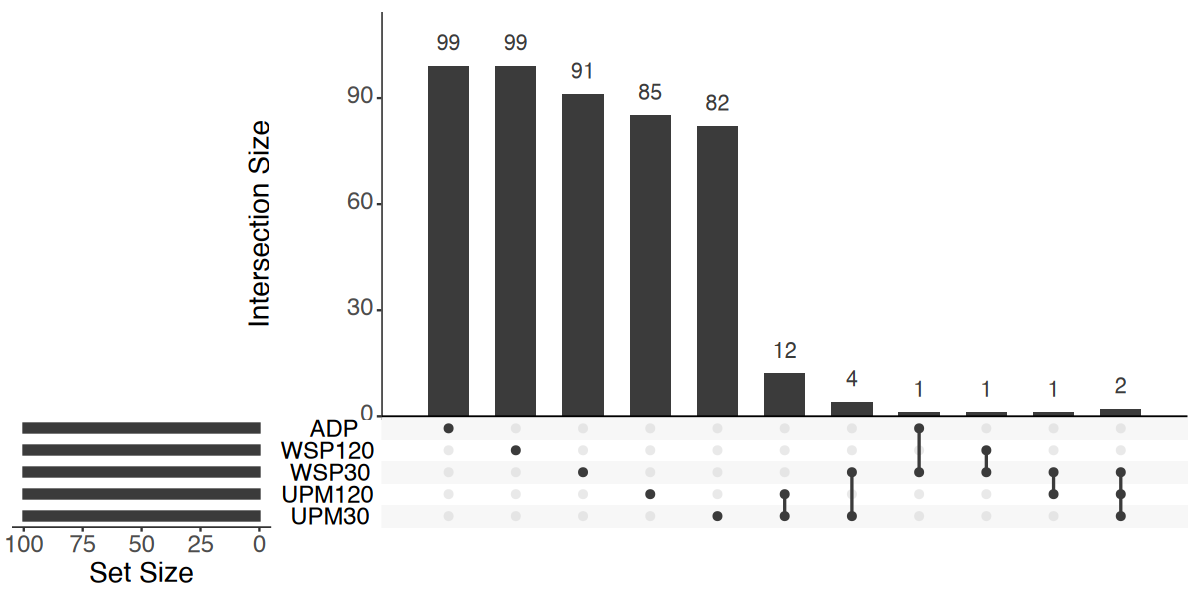

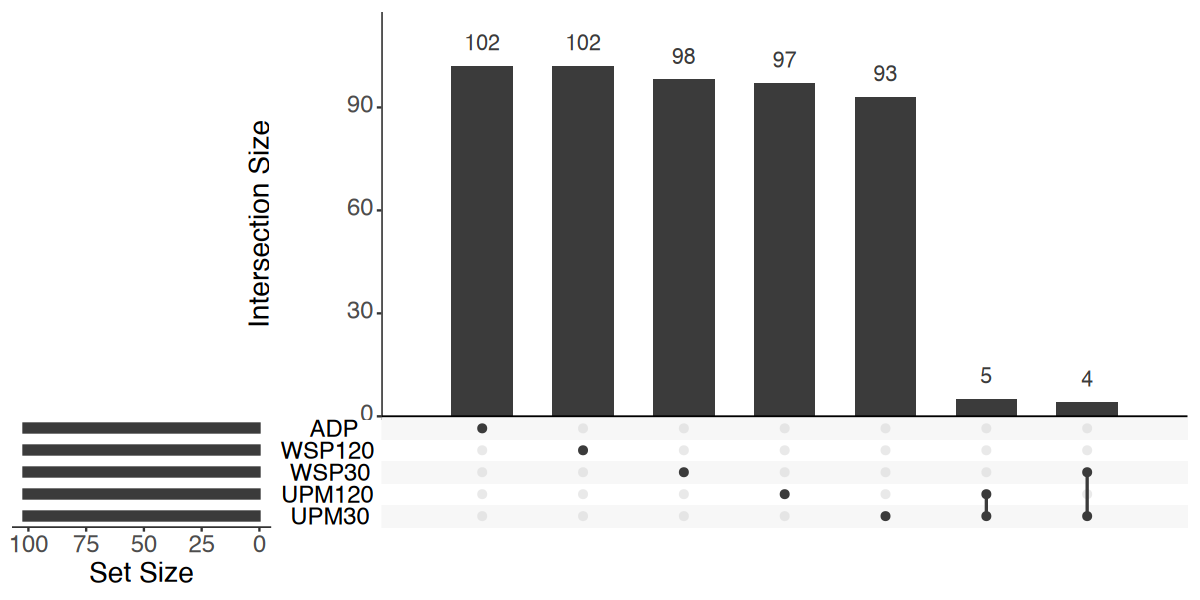

In [14]:
options(repr.plot.width=10, repr.plot.height=5)
upset(fromList(list("ADP"=res_ADP_list$UP15, "WSP120"=res_W120_list$UP15, "WSP30"=res_W30_list$UP15, 
                    "UPM120"=res_U120_list$UP15, "UPM30"=res_U30_list$UP15)), text.scale=2, nsets=5)

upset(fromList(list("ADP"=res_ADP_list$DOWN15, "WSP120"=res_W120_list$DOWN15, "WSP30"=res_W30_list$DOWN15, 
                    "UPM120"=res_U120_list$DOWN15, "UPM30"=res_U30_list$DOWN15)), text.scale=2, nsets=5)

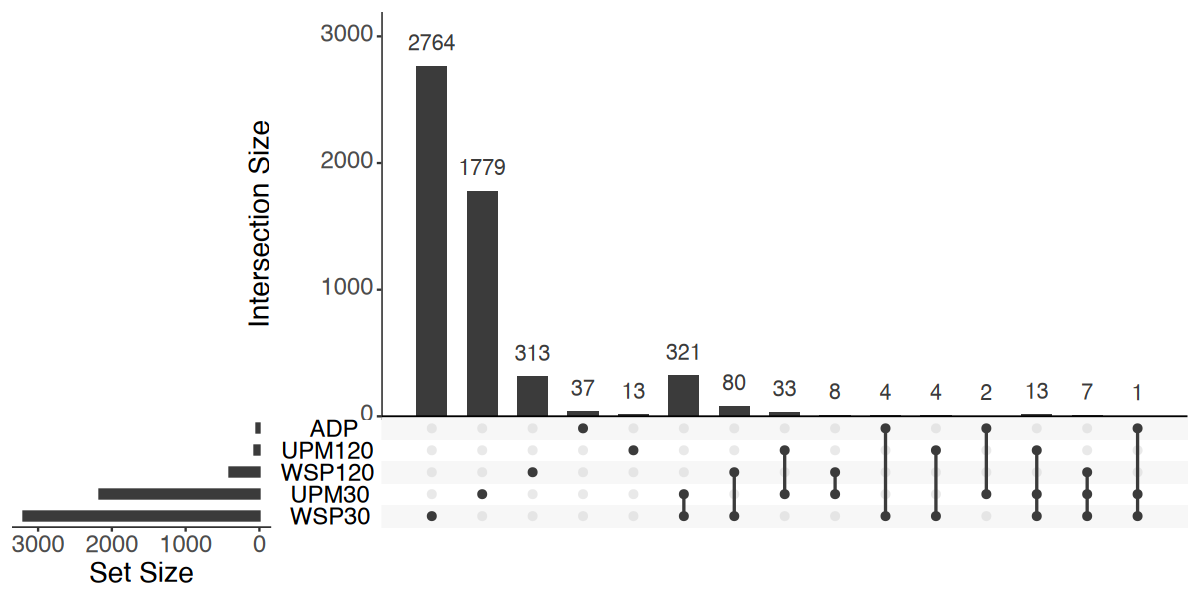

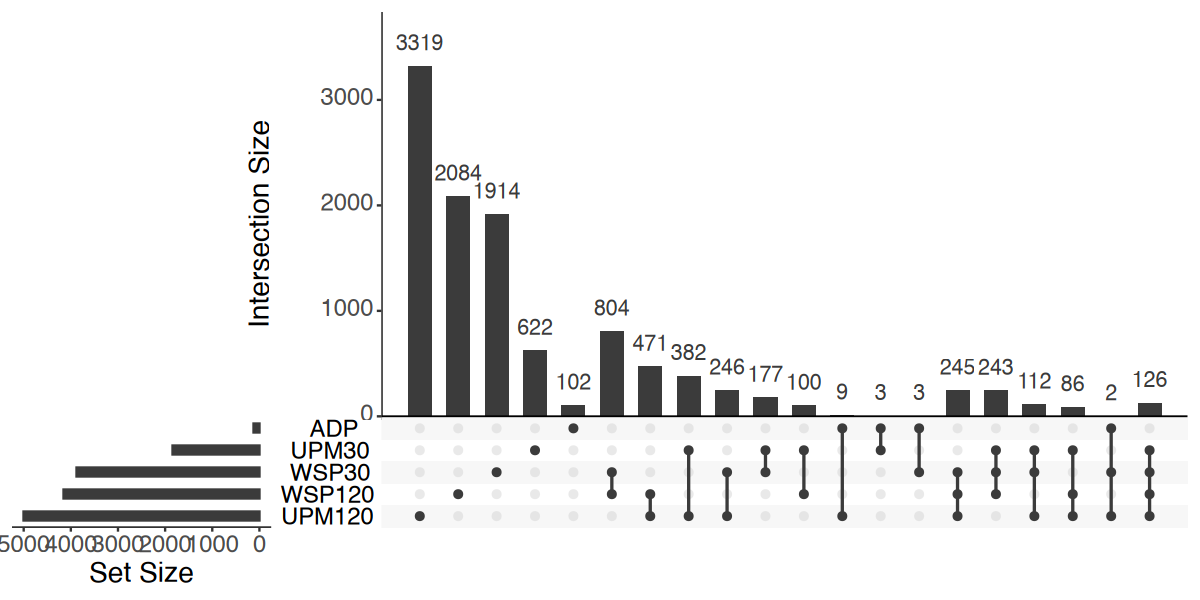

In [16]:
options(repr.plot.width=10, repr.plot.height=5)
upset(fromList(list("ADP"=res_ADP_list$UPSIG, "WSP120"=res_W120_list$UPSIG, "WSP30"=res_W30_list$UPSIG, 
                    "UPM120"=res_U120_list$UPSIG, "UPM30"=res_U30_list$UPSIG)), text.scale=2, nsets=5)

upset(fromList(list("ADP"=res_ADP_list$DOWNSIG, "WSP120"=res_W120_list$DOWNSIG, "WSP30"=res_W30_list$DOWNSIG, 
                    "UPM120"=res_U120_list$DOWNSIG, "UPM30"=res_U30_list$DOWNSIG)), text.scale=2, nsets=5)

In [15]:
# add info about Perturbation and timing
res_ADP_list$res$Source <- "ADP"
res_ADP_list$res$Time <- "20h"
res_W120_list$res$Source <- "WSP"
res_W120_list$res$Time <- "120m"
res_W30_list$res$Source <- "WSP"
res_W30_list$res$Time <- "30m"
res_U120_list$res$Source <- "UPM"
res_U120_list$res$Time <- "120m"
res_U30_list$res$Source <- "UPM"
res_U30_list$res$Time <- "30m"

plot_df <- rbind(res_ADP_list$res, rbind(res_W120_list$res, rbind(res_W30_list$res, rbind(res_U120_list$res, res_U30_list$res))))
plot_df[1:2,]

plot_df$Sig <- "NonSig"
plot_df[plot_df$padj < 1e-6,]$Sig <- "Sig"
plot_df$Source_Time <- paste0(plot_df$Source, "_", plot_df$Time)

V1,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Source,Time
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
chr5:53288231-53288949,210.02030,3.930830,0.5648053,6.95962,3.411913e-12,2.836445e-08,ADP,20h
chr22:37545127-37545883,93.13459,4.276609,0.6577962,6.50142,7.956516e-11,3.054507e-07,ADP,20h


In [16]:
# Get the UPM genes with the greatest signfiicance across the different time points
names(UPM_1_time_sig)

top_genes = list()


for (timepoint in names(UPM_1_time_sig)) {
    if (timepoint %in% c("ER", "EF", "EPR", "EPF")) {
    filt = res_U30_list$res[res_U30_list$res$V1 %in% UPM_1_time_sig[[timepoint]],]
    # get top two by p-value sig
    top_genes[[timepoint]] = filt[order(filt$padj, -filt$log2FoldChange),]$V1[1:10]
    } else if  (timepoint %in% c("LR", "LF")) {
    filt = res_U120_list$res[res_U120_list$res$V1 %in% UPM_1_time_sig[[timepoint]],]
    # get top two by p-value sig
    top_genes[[timepoint]] = filt[order(filt$padj, -filt$log2FoldChange),]$V1[1:10]
    } else {print("ERROR")}
    }

[1] "ER"  "EF"  "EPR" "EPF" "LR"  "LF"

In [23]:
top_genes

$ER
 [1] "chr3:138625868-138626308"  "chr12:122851670-122852178"
 [3] "chr1:150536683-150537235"  "chr1:46022897-46023447"   
 [5] "chr2:9307051-9307339"      "chr20:47668642-47669144"  
 [7] "chr5:61289830-61290134"    "chr3:31664984-31665636"   
 [9] "chr11:48055505-48056209"   "chr12:122852603-122852985"

$EF
 [1] "chr11:118924478-118924854" "chr19:41318991-41319451"  
 [3] "chr5:176365824-176366280"  "chrX:107643889-107644423" 
 [5] "chr17:64385131-64385887"   "chr3:61250118-61250392"   
 [7] "chr11:77066501-77066691"   "chr17:3724018-3724350"    
 [9] "chr8:52564132-52565196"    "chr7:65239729-65240131"   

$EPR
 [1] "chr5:372805-373803"       "chr15:74763269-74764007" 
 [3] "chr15:74651036-74651680"  "chr22:43263953-43264659" 
 [5] "chr1:43883355-43883865"   "chr19:2150938-2151414"   
 [7] "chr6:2031059-2031461"     "chr2:121205471-121205973"
 [9] "chr17:81465919-81466095"  "chr17:349592-350032"     

$EPF
 [1] "chr9:114156552-114157050" "chr1:205505710-205506152"
 [3] "chr1:43270423-43270783"   "chr8:80872580-80873716"  
 [5] "chr17:7559745-7560155"    "chr1:203628296-203629312"
 [7] "chr1:41917992-41918398"   "chr7:140229545-140230299"
 [9] "chr7:127992458-127992942" "chr22:43152288-43152658" 

$LR
 [1] "chr8:73366728-73367246"   "chr19:41791080-41791412" 
 [3] "chr3:156725457-156725965" "chr8:73364055-73364429"  
 [5] "chr5:367862-368844"       "chr15:99479860-99482716" 
 [7] "chr8:141167570-141169826" "chr8:141177478-141178014"
 [9] "chr15:99477656-99478028"  "chr8:141173113-141173493"

$LF
 [1] "chr8:26265945-26266391"   "chr16:85017278-85017626" 
 [3] "chr17:78334534-78335160"  "chr2:45821935-45822395"  
 [5] "chr3:187740822-187741272" "chr18:77129205-77129539" 
 [7] "chr1:202058232-202058794" "chr10:24209727-24210491" 
 [9] "chr13:24630353-24631263"  "chr1:41498475-41499239"

### Plotting L2FC

[1] 4

character(0)

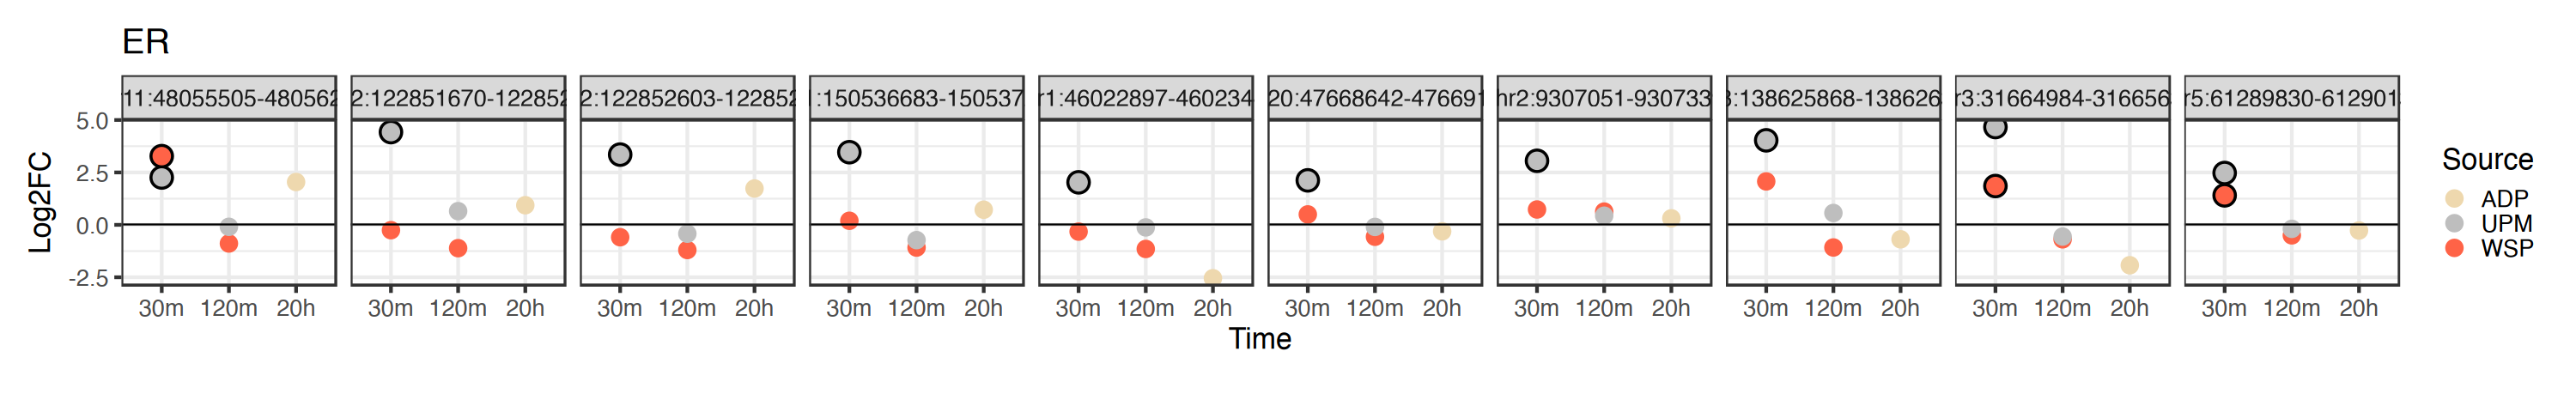

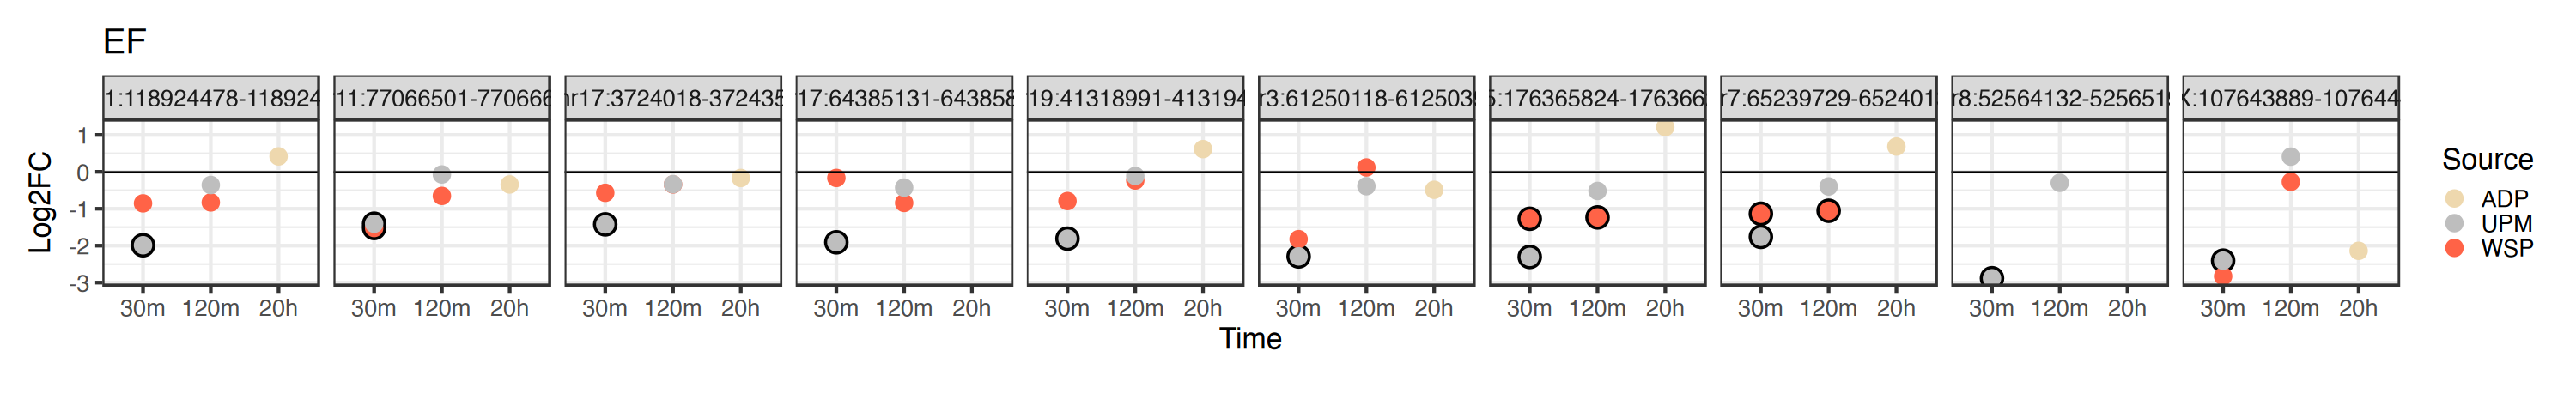

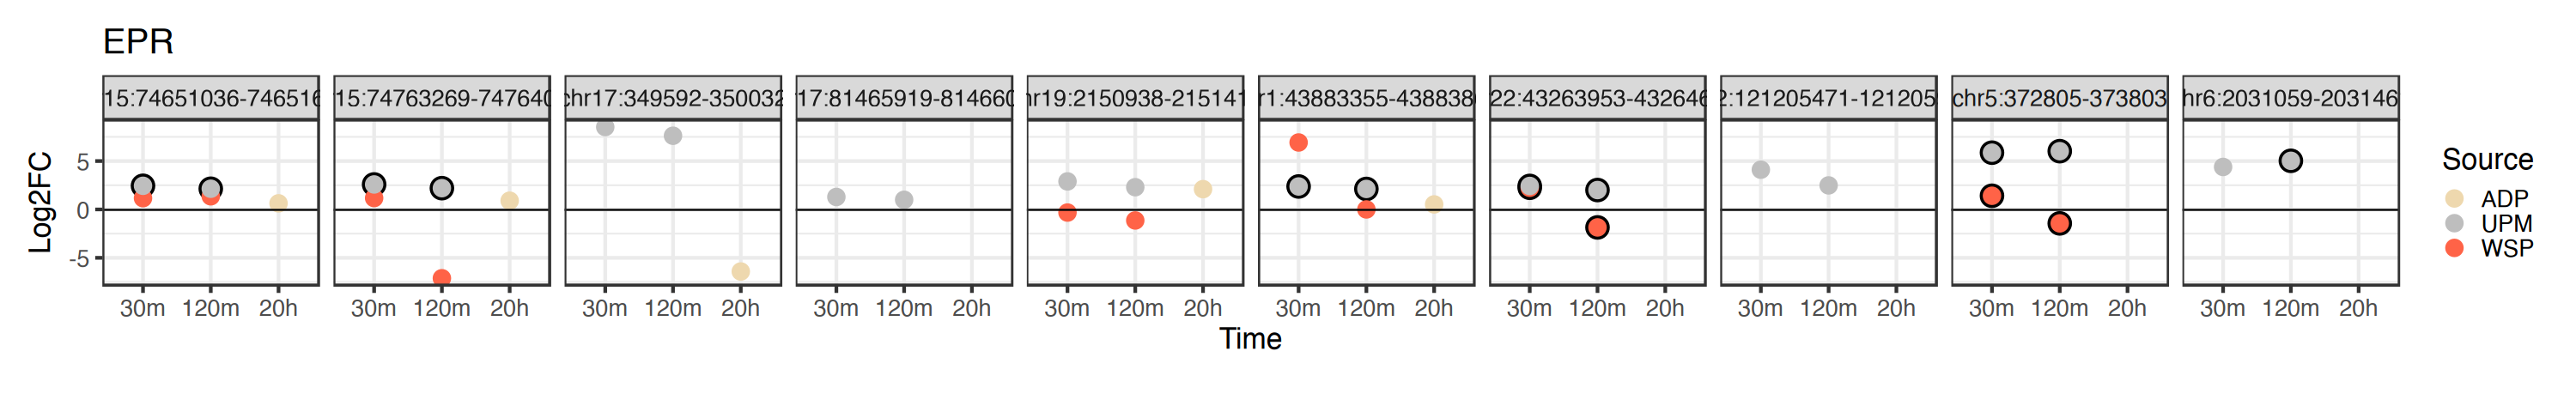

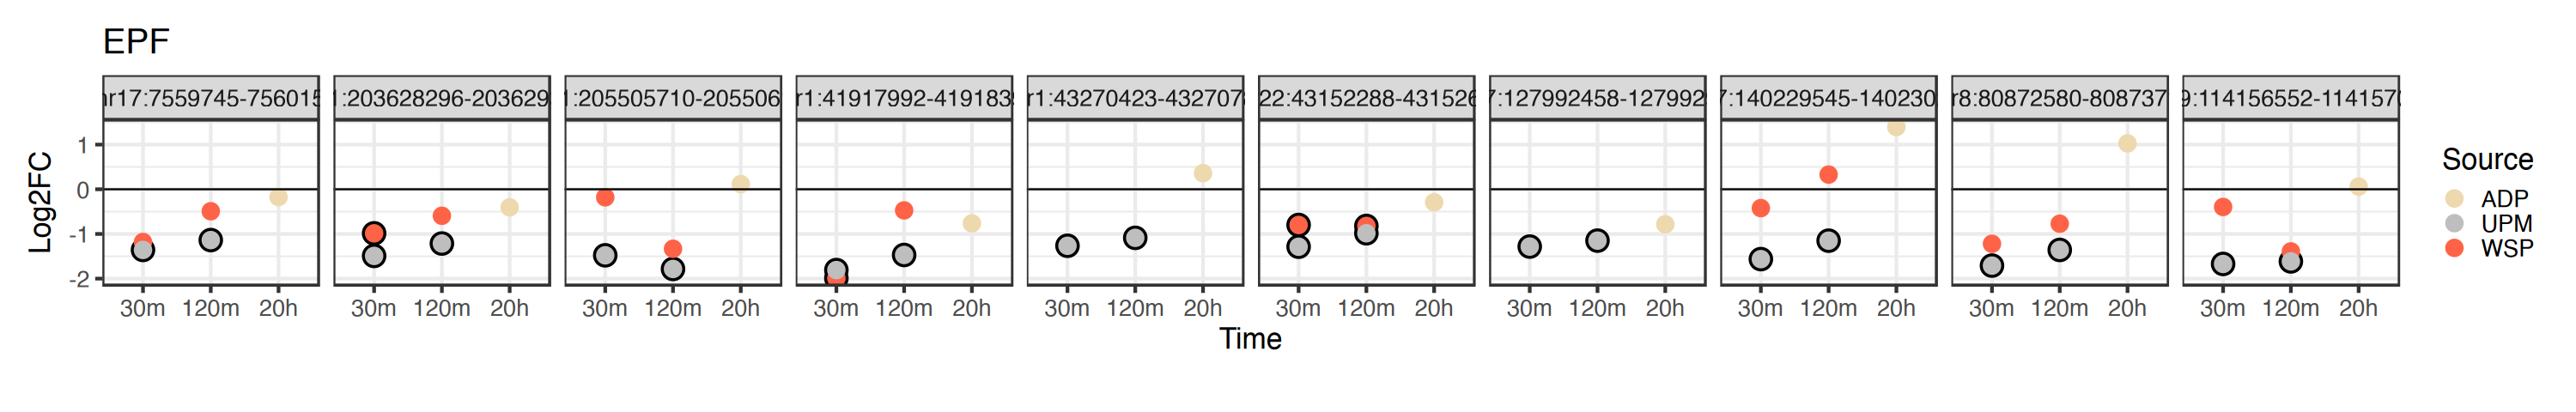

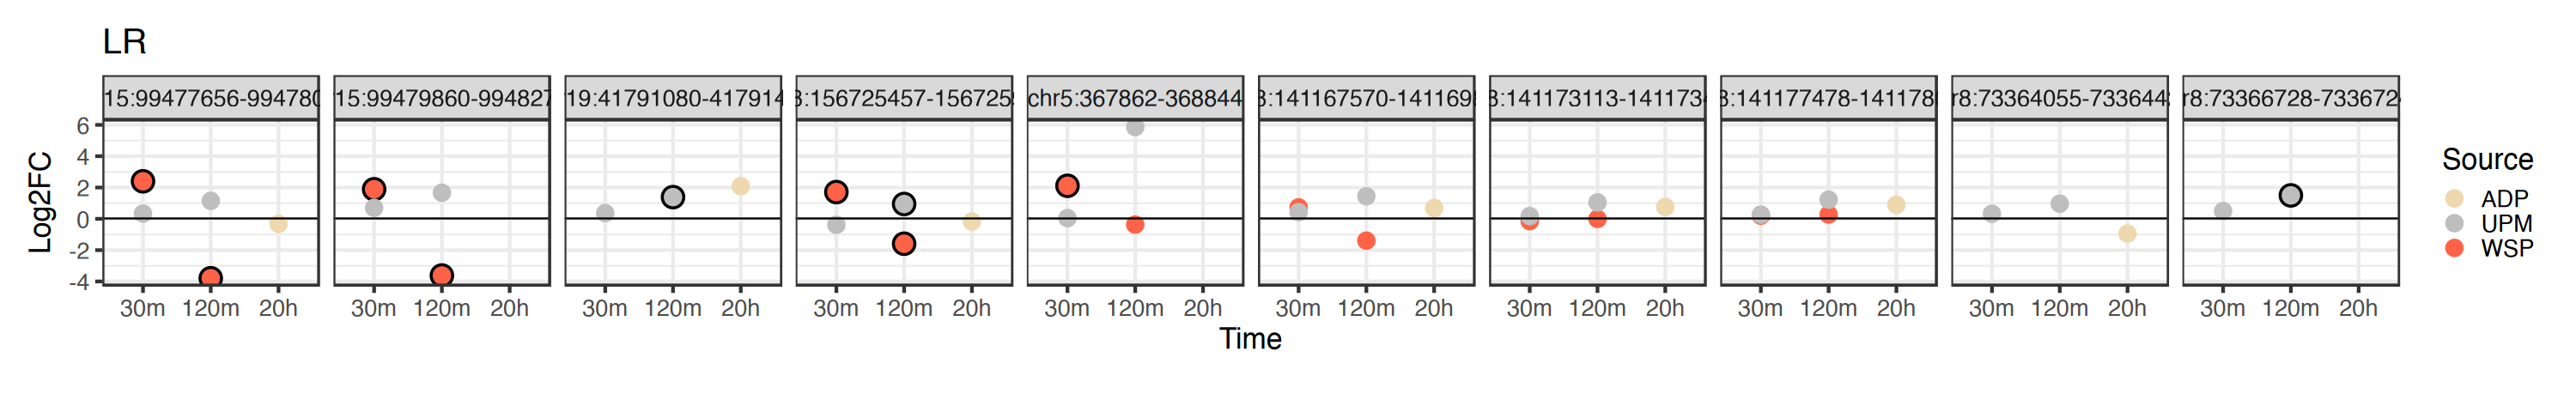

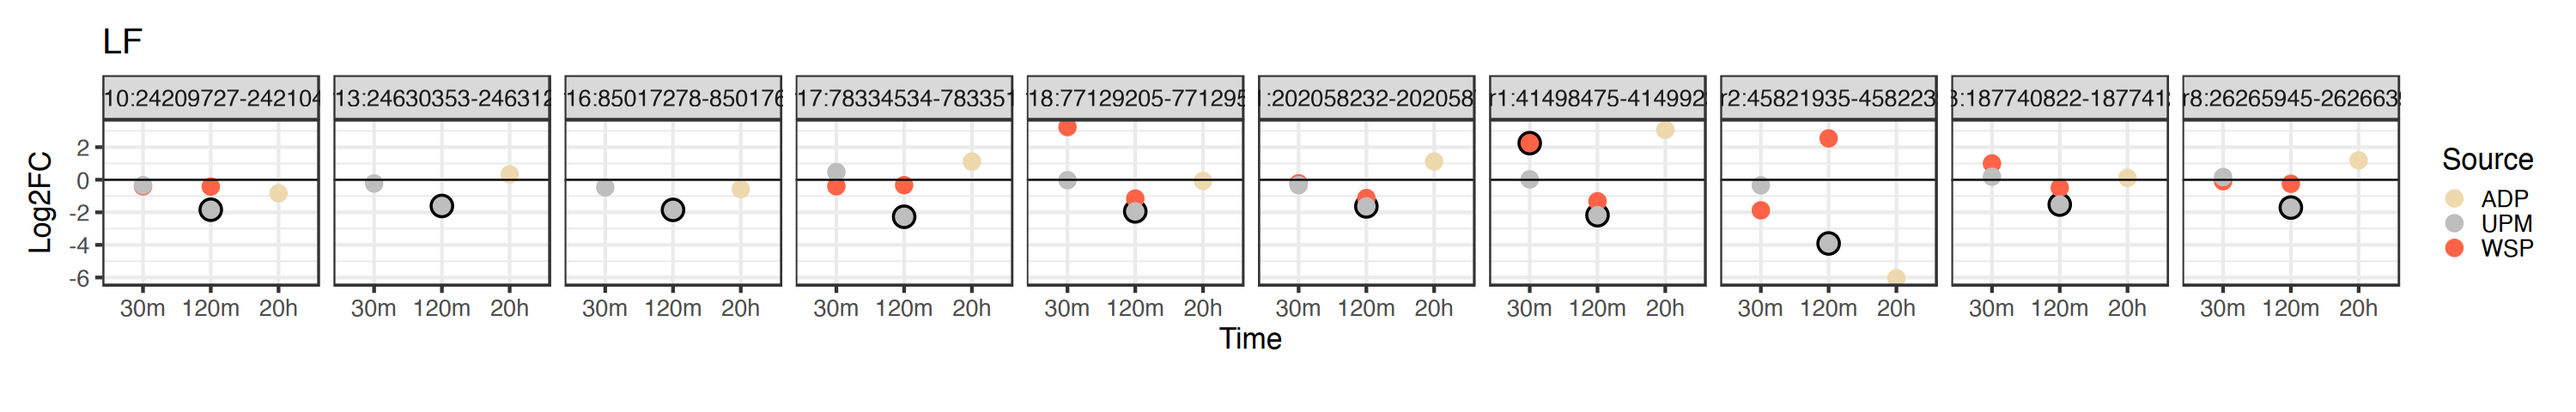

In [17]:
use_genes = unlist(top_genes)
color_map = c("ADP"="wheat2", "WSP"="tomato", "UPM"="grey")
#* No clear signal for HAPLN (HYA binding proteins)

height_use = 4
height_use
options(repr.plot.height=height_use, repr.plot.width=25)
setdiff(use_genes, plot_df$V1)
#pdf("UPM_LFC_spec_tREs.pdf", height=height_use, width=6.5)
for (timepoint in names(top_genes)) {
    use_genes = top_genes[[timepoint]]
    plot_df_use = plot_df[plot_df$V1 %in% use_genes,]
    plot_df_use$Time <- factor(plot_df_use$Time, levels=c("30m", "120m", "20h"))
p <- ggplot(plot_df_use, 
       aes(x=Time, y=log2FoldChange, color=Source)) + 
    scale_x_discrete(drop = FALSE) +
        geom_point(data=plot_df_use[plot_df_use$Sig == "Sig",], color="black", size=7) +
       geom_point(size=5) + theme_bw(base_size=20) + geom_hline(yintercept=0) + labs(x="Time", y="Log2FC") +
scale_color_manual(values=color_map) +
    ggtitle(timepoint) + facet_wrap(~V1, nrow=1) + 
theme(plot.margin = margin(t = 20, r = 20, b = 40, l = 20))  # top, right, bottom, left in pts
print(p)}
#dev.off()

### Plotting Normalized Counts

In [18]:
# read in the counts
counts_upm <- fread("../results/DESeq2/UPM_nontss_normalized_counts.txt")
counts_upm[1:2,]
counts_wsp <- fread("../results/DESeq2/WSP_nontss_normalized_counts.txt")
counts_wsp[1:2,]

# Convert wide to long
counts_upm_long <- counts_upm %>%
  pivot_longer(
    cols = -Gene,
    names_to = "Sample",
    values_to = "Count"
  ) %>%
  # Extract Time and Replicate info
  mutate(
    Time = case_when(
      grepl("UPM120", Sample) ~ "120",
      grepl("UPM30", Sample) ~ "30",
      grepl("Veh", Sample) ~ "0"
    ),
    Replicate = sub(".*_(\\d+)", "Rep\\1", Sample)
  )

counts_wsp_long <- counts_wsp %>%
  pivot_longer(
    cols = -Gene,
    names_to = "Sample",
    values_to = "Count"
  ) %>%
  # Extract Time and Replicate info
  mutate(
    Time = case_when(
      grepl("WSP120", Sample) ~ "120",
      grepl("WSP30", Sample) ~ "30",
      grepl("Veh", Sample) ~ "0"
    ),
    Replicate = sub(".*_(\\d+)", "Rep\\1", Sample)
  )

# Optional: factor levels for ordered time
counts_upm_long$Time <- factor(counts_upm_long$Time, levels = c("0", "30", "120"))
counts_wsp_long$Time <- factor(counts_wsp_long$Time, levels = c("0", "30", "120"))

counts_upm_long[1:2,]
counts_wsp_long[1:2,]



UPM120_1,UPM120_2,UPM30_1,UPM30_2,Veh_1,Veh_2,Gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
535.9884,515.0712,745.984818,812.53713,916.2887,1136.0651,chr1:1133229-1133779
317.2908,312.7587,1.222926,62.71888,282.2408,280.5214,chr1:1353573-1354013


Veh_1,Veh_2,WSP30_1,WSP30_2,WSP120_1,WSP120_2,Gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
16.87159,21.897596,24.68264,30.42470,59.34804,56.97226,chr1:785582-786076
18.07671,8.067535,19.74611,18.06467,21.66675,34.67877,chr1:805310-805780


Gene,Sample,Count,Time,Replicate
<chr>,<chr>,<dbl>,<fct>,<chr>
chr1:1133229-1133779,UPM120_1,535.9884,120,Rep1
chr1:1133229-1133779,UPM120_2,515.0712,120,Rep2


Gene,Sample,Count,Time,Replicate
<chr>,<chr>,<dbl>,<fct>,<chr>
chr1:785582-786076,Veh_1,16.87159,0,Rep1
chr1:785582-786076,Veh_2,21.89760,0,Rep2


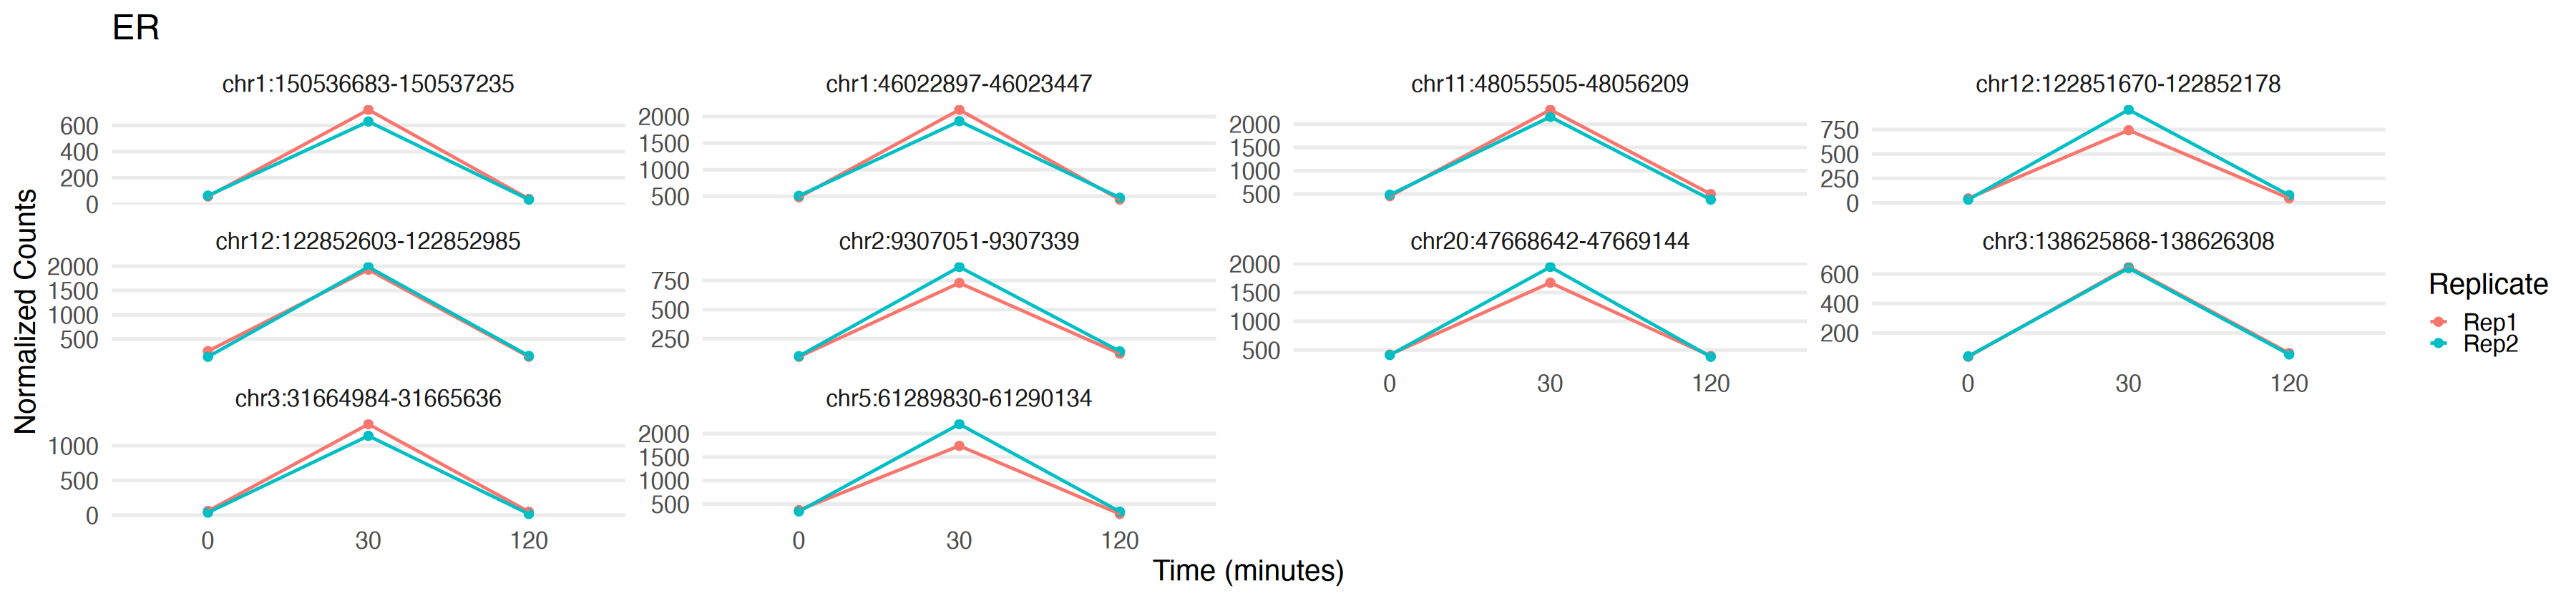

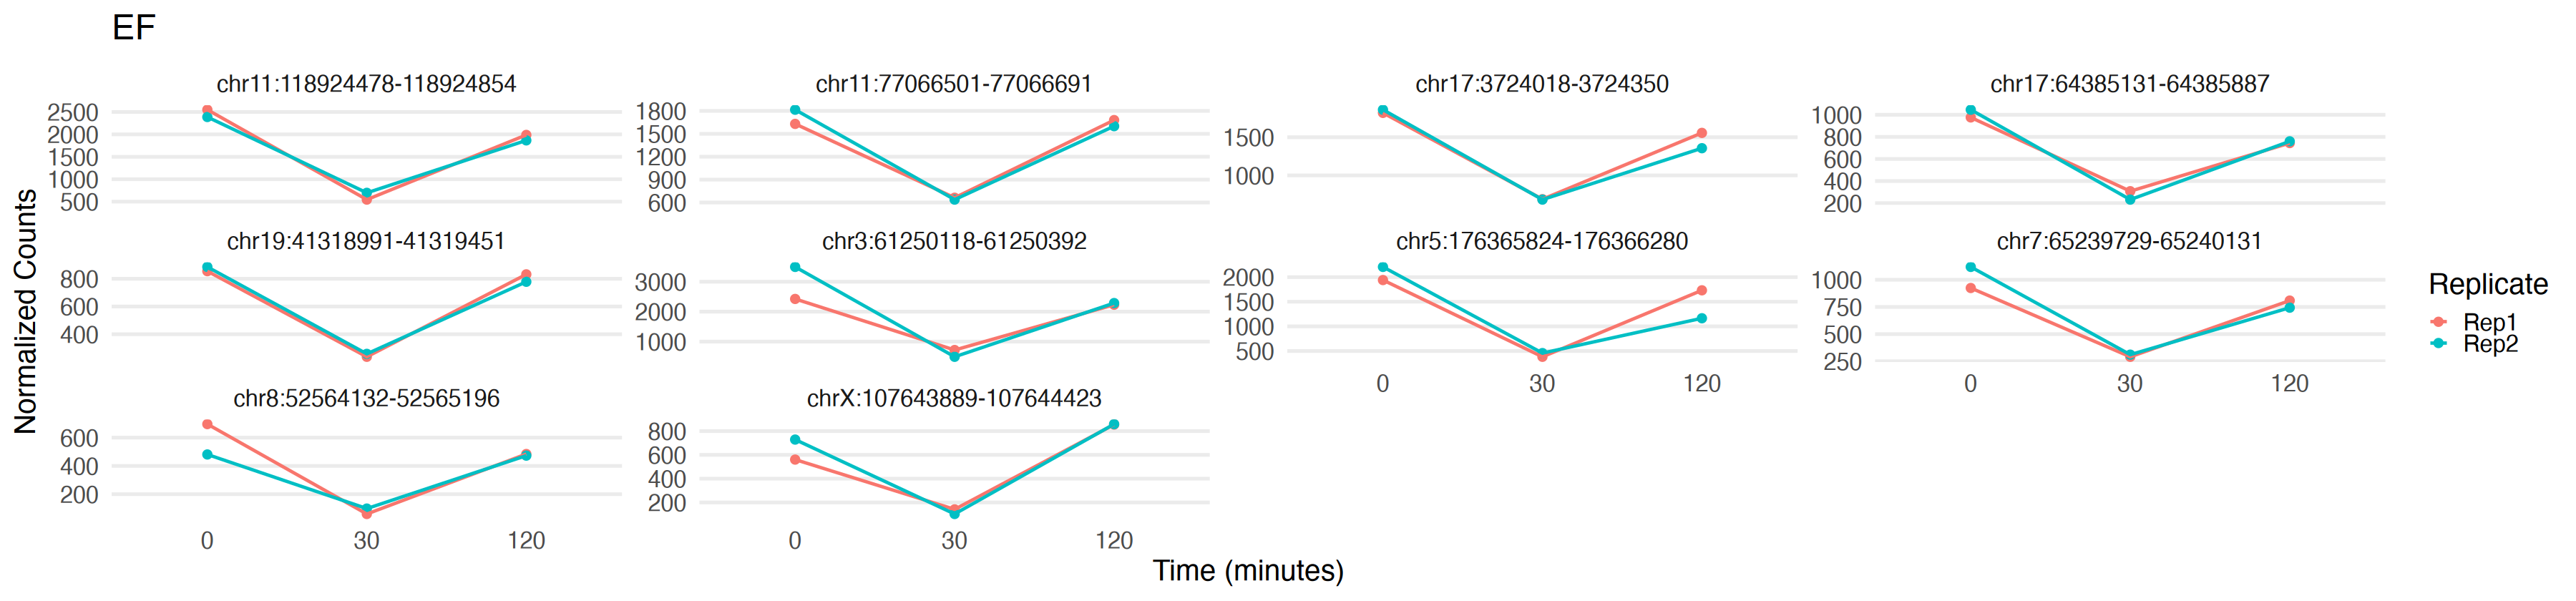

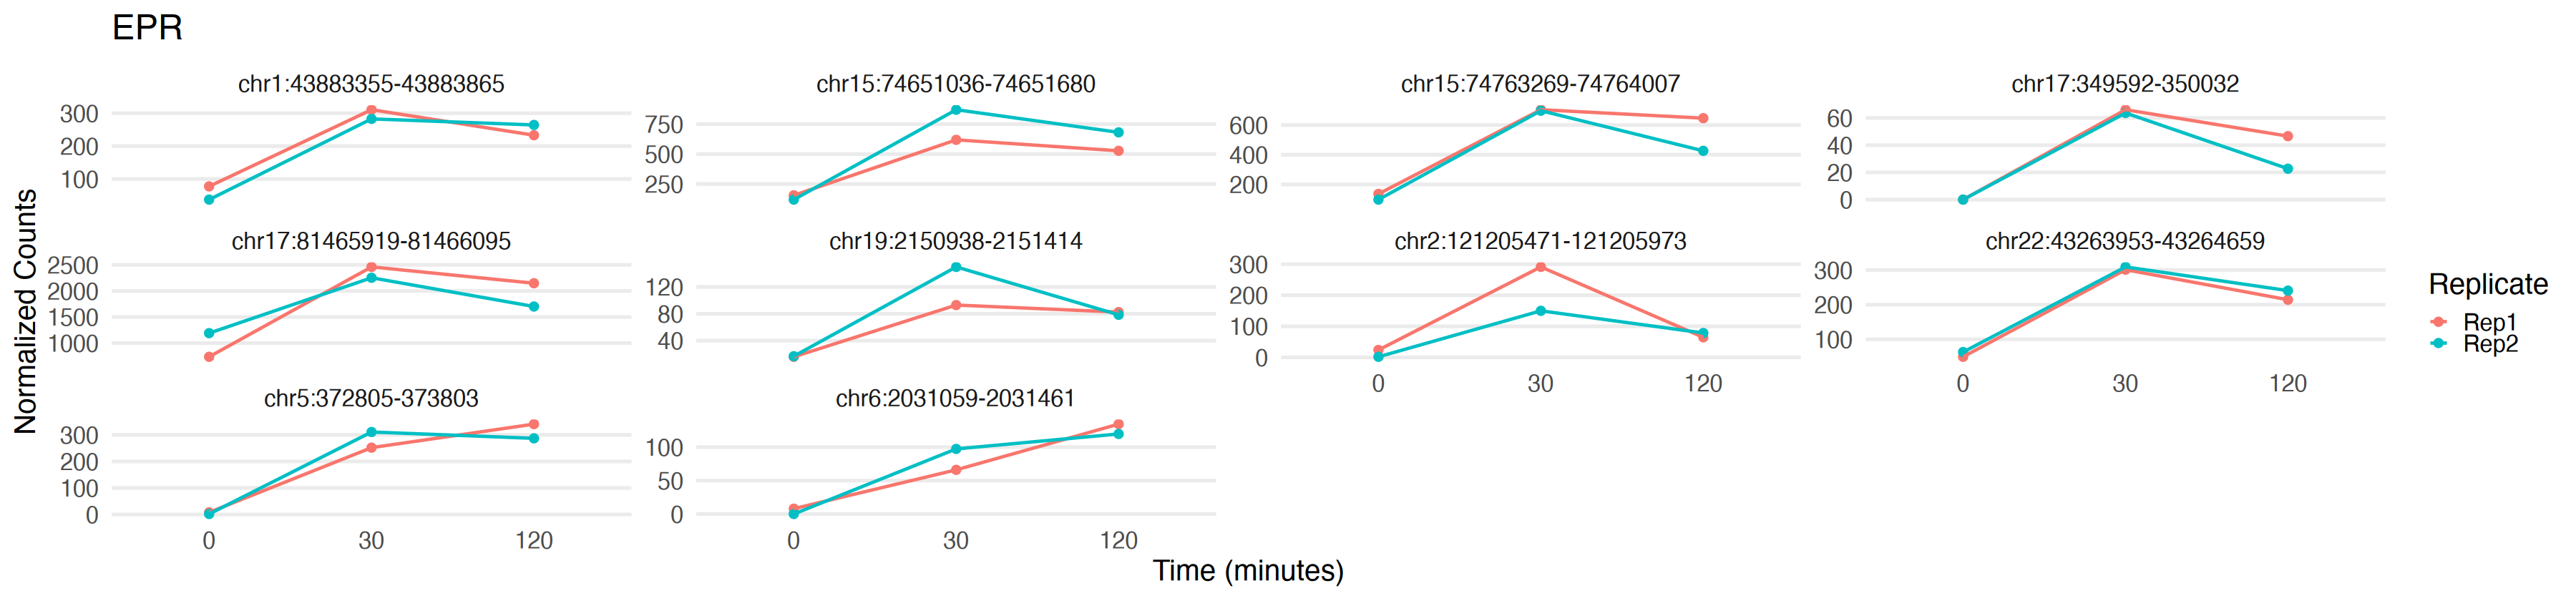

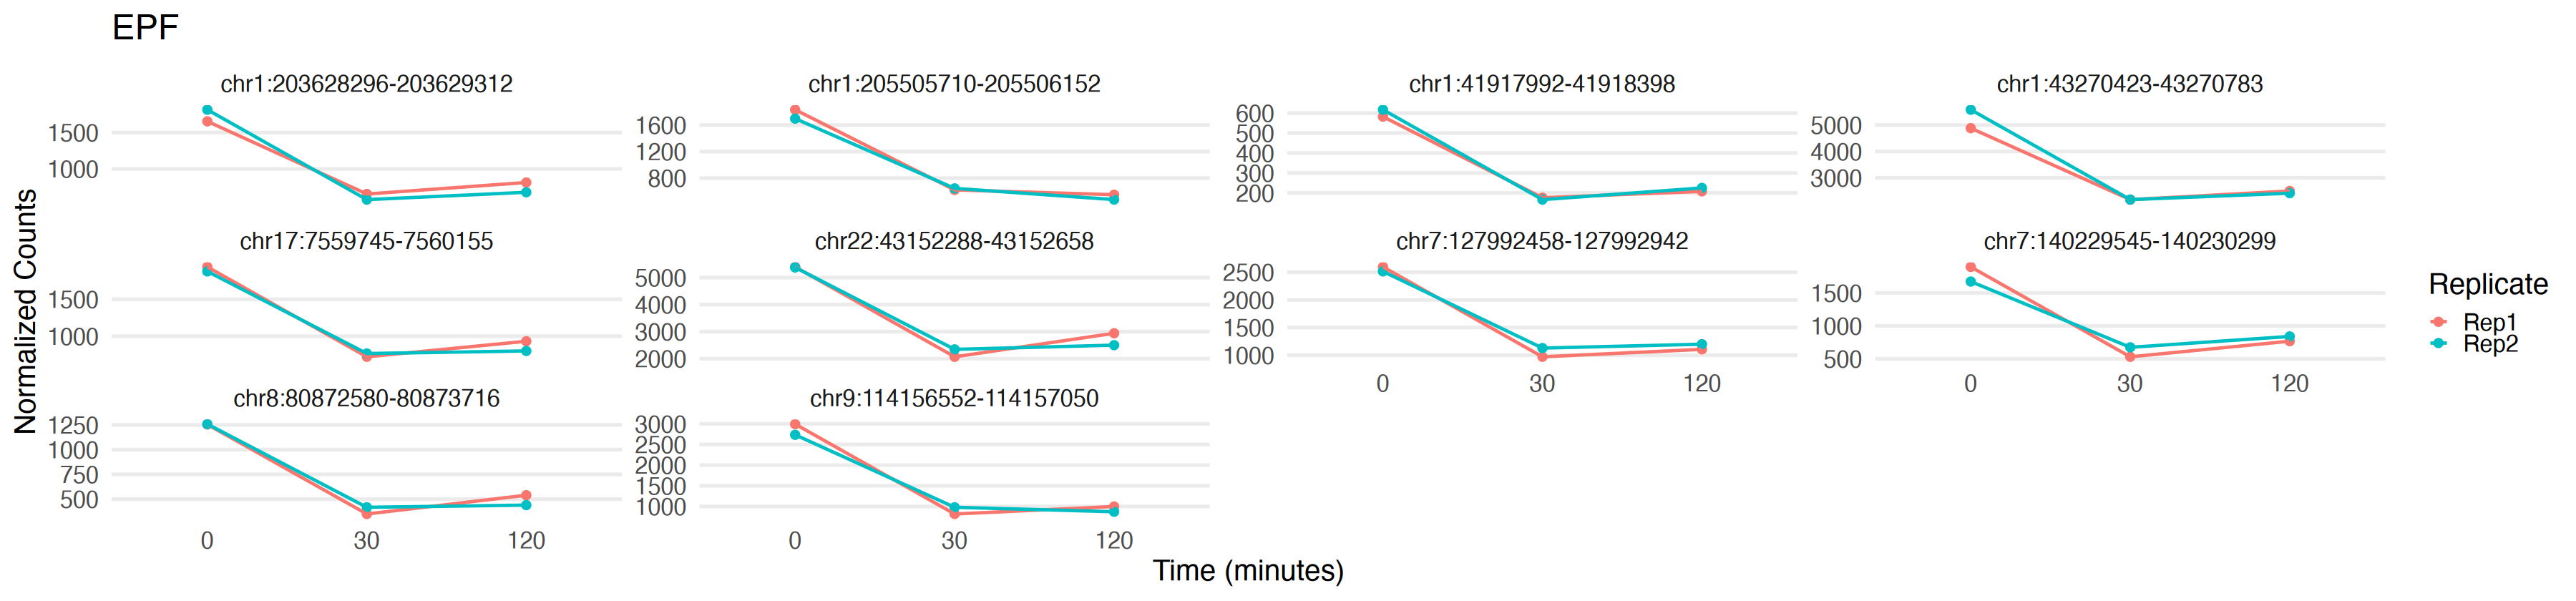

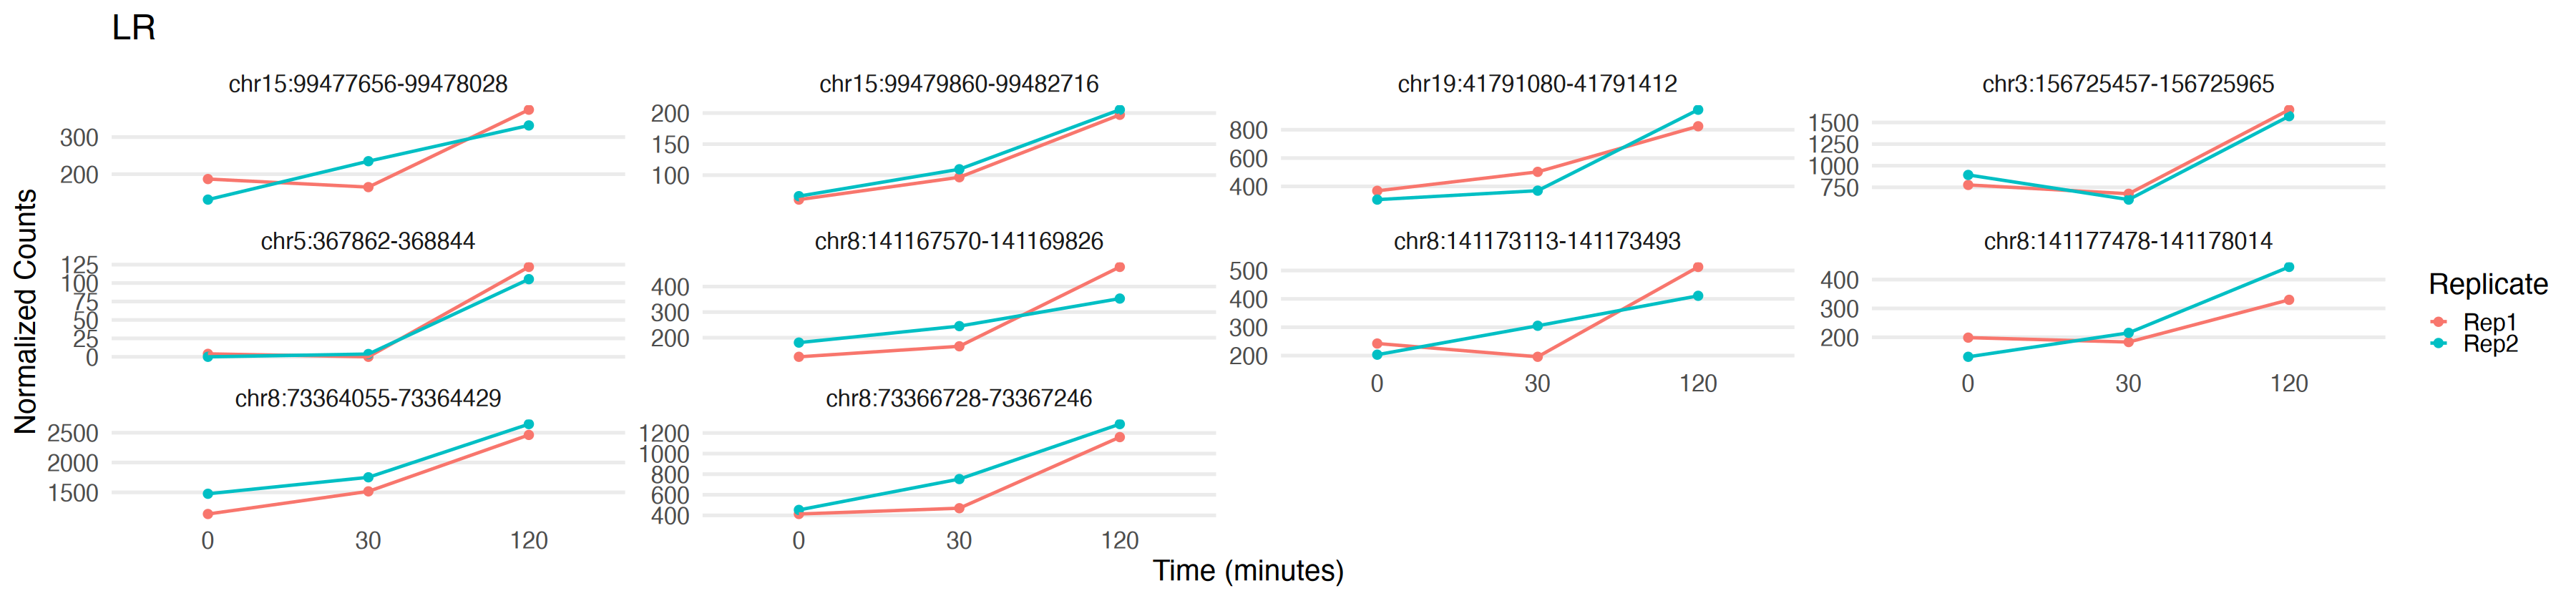

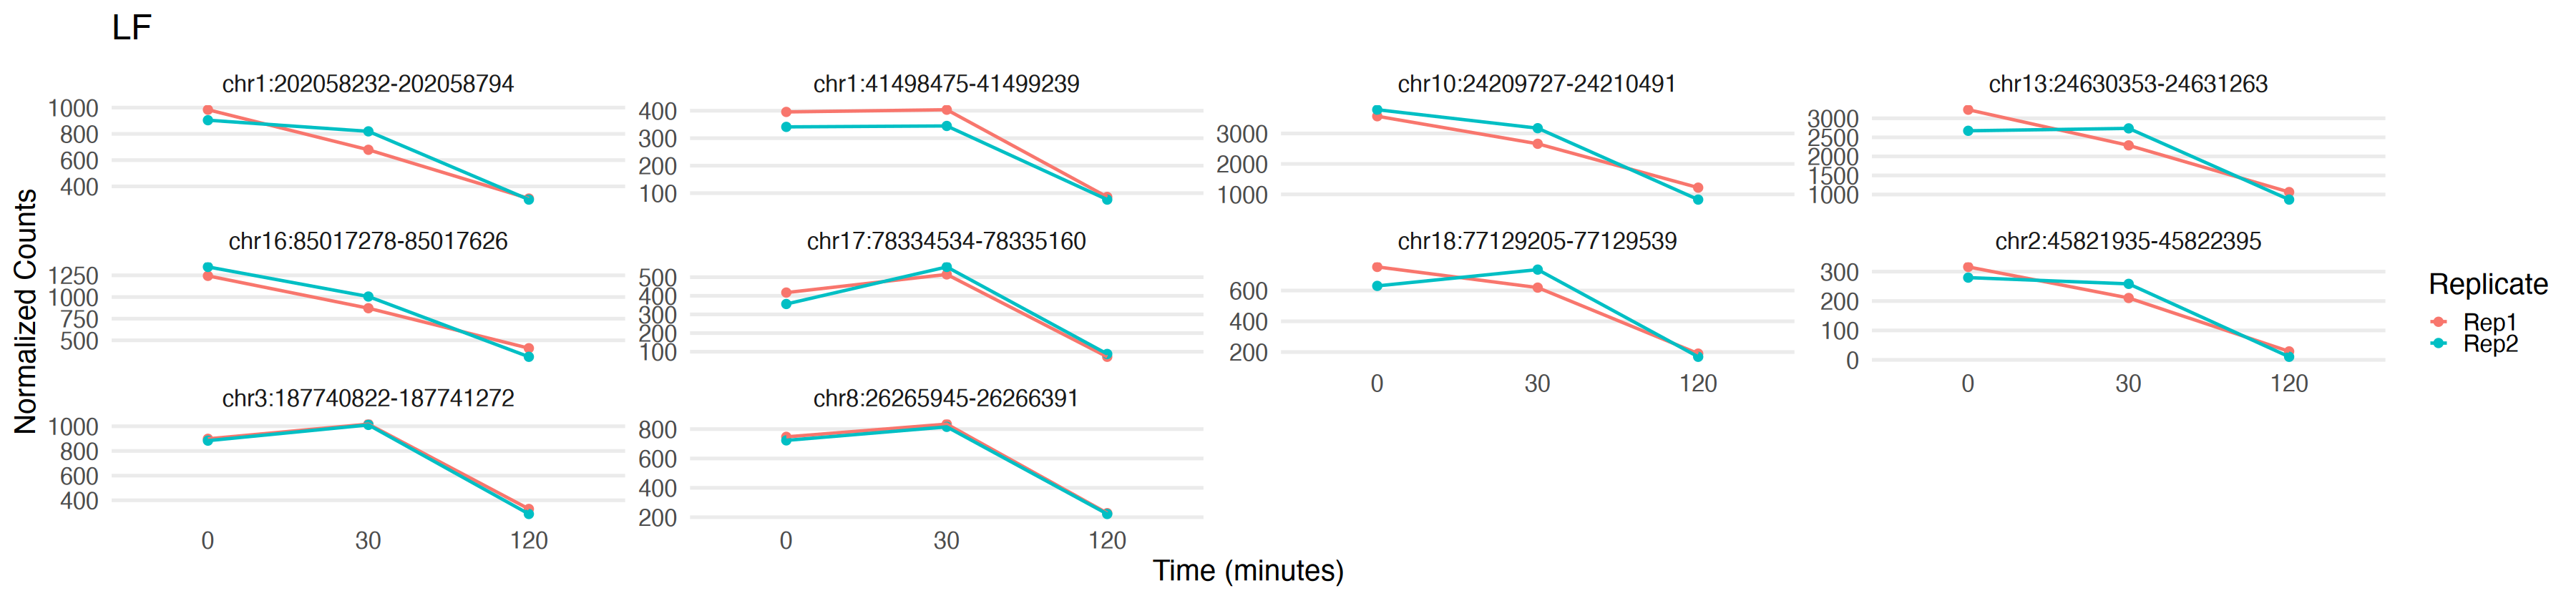

In [31]:
options(repr.plot.height=7, repr.plot.width=30)
for (timepoint in names(top_genes)) {
    use_genes = top_genes[[timepoint]]
    # Plot: one line per replicate, faceted by gene
    counts_long_plot = counts_long[counts_long$Gene %in% use_genes,]
    p = ggplot(counts_long_plot, aes(x = Time, y = Count, group = Replicate, color = Replicate)) +
      geom_point(size = 3) +
      geom_line(linewidth = 1) +
      facet_wrap(~Gene, scales = "free_y") +
      theme_minimal(base_size = 24) +
      labs(title = timepoint, x = "Time (minutes)", y = "Normalized Counts") +
      theme(strip.text = element_text(face = "bold"), panel.grid.major.x = element_blank(),  # Remove vertical grid lines
    panel.grid.minor.y = element_blank())  
print(p)}

In [19]:
counts_upm_scaled <- counts_upm_long %>%
  group_by(Gene) %>%
  mutate(
    Scaled = (Count - min(Count)) / (max(Count) - min(Count))
  ) %>%
  ungroup()

counts_wsp_scaled <- counts_wsp_long %>%
  group_by(Gene) %>%
  mutate(
    Scaled = (Count - min(Count)) / (max(Count) - min(Count))
  ) %>%
  ungroup()

In [21]:
dim(counts_upm_scaled)
counts_upm_scaled[1:2,]
names(UPM_1_time_sig)



[1] 321186      6

Gene,Sample,Count,Time,Replicate,Scaled
<chr>,<chr>,<dbl>,<fct>,<chr>,<dbl>
chr1:1133229-1133779,UPM120_1,535.9884,120,Rep1,0.03368337
chr1:1133229-1133779,UPM120_2,515.0712,120,Rep2,0.00000000


[1] "ER"  "EF"  "EPR" "EPF" "LR"  "LF"

In [23]:
check = counts_upm_scaled[counts_upm_scaled$Gene %in% UPM_1_time_sig[["ER"]],]
dim(check)
check[1:4,]

[1] 19740     6

Gene,Sample,Count,Time,Replicate,Scaled
<chr>,<chr>,<dbl>,<fct>,<chr>,<dbl>
chr1:39819363-39819809,UPM120_1,112.0377,120,Rep1,0.04437353
chr1:39819363-39819809,UPM120_2,108.3817,120,Rep2,0.03531514
chr1:39819363-39819809,UPM30_1,497.7309,30,Rep1,1.00000000
chr1:39819363-39819809,UPM30_2,450.2654,30,Rep2,0.88239549


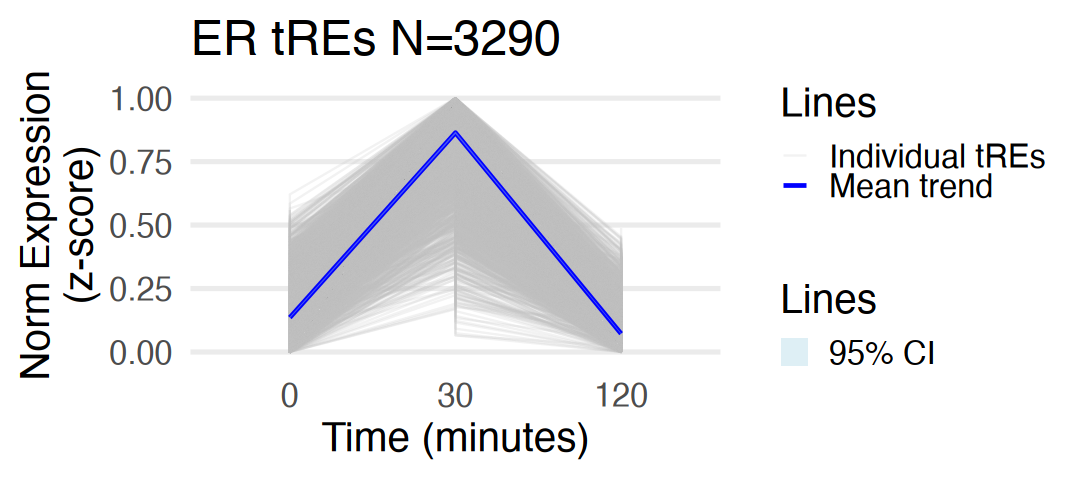

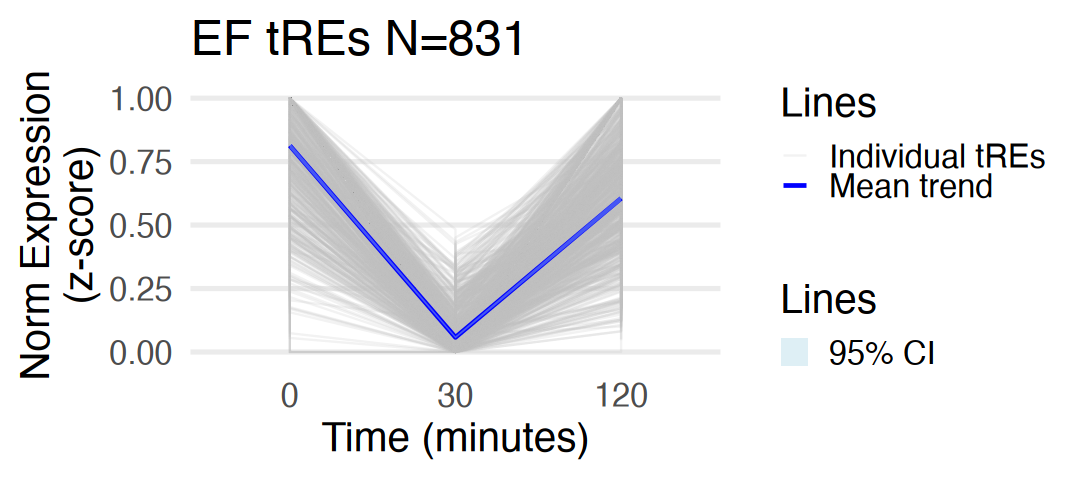

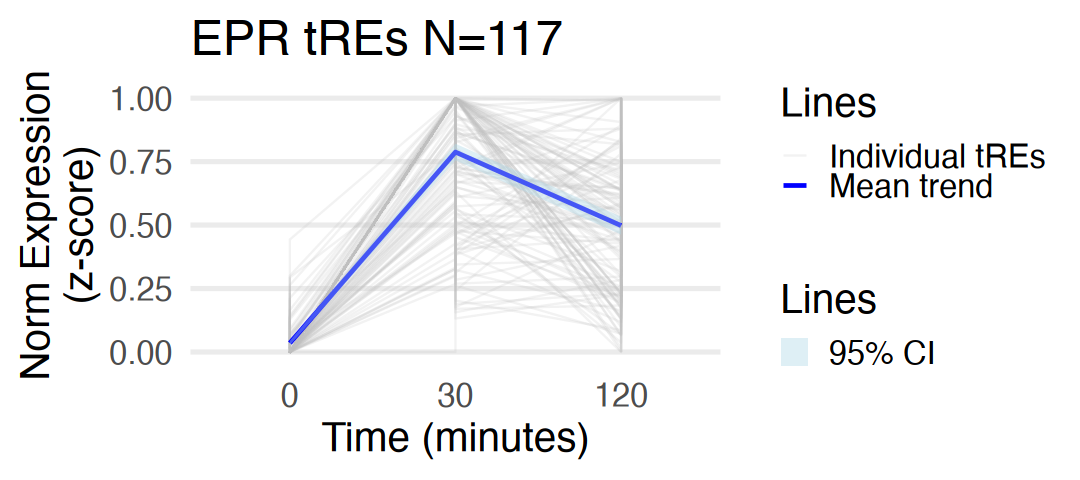

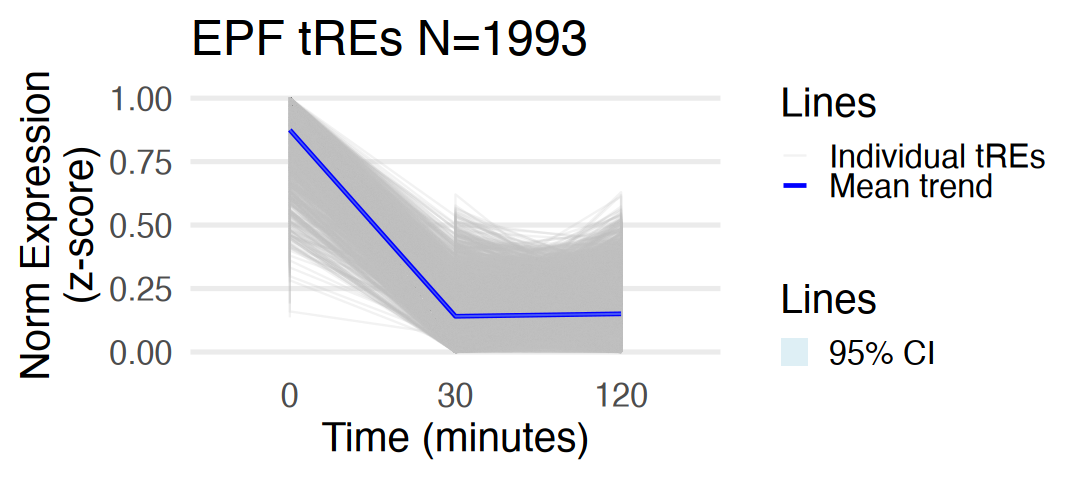

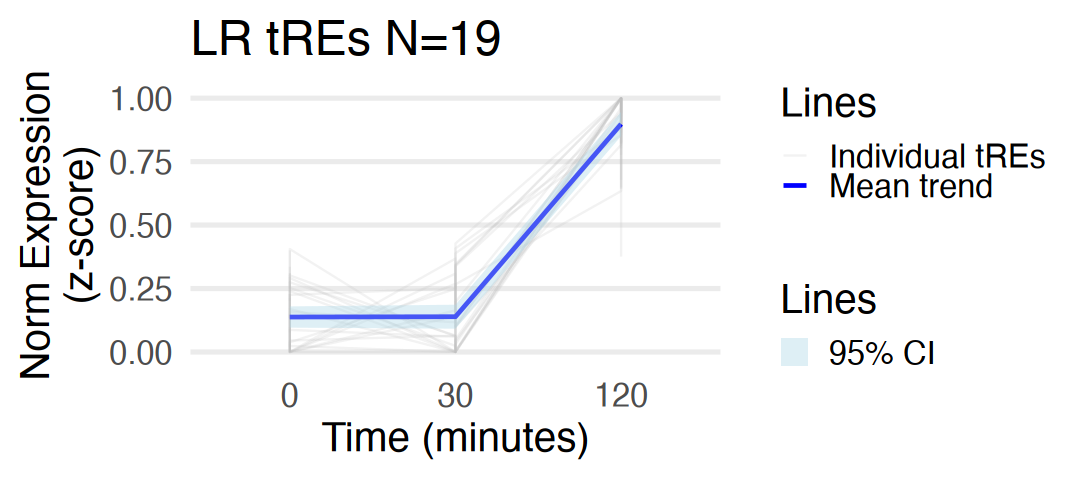

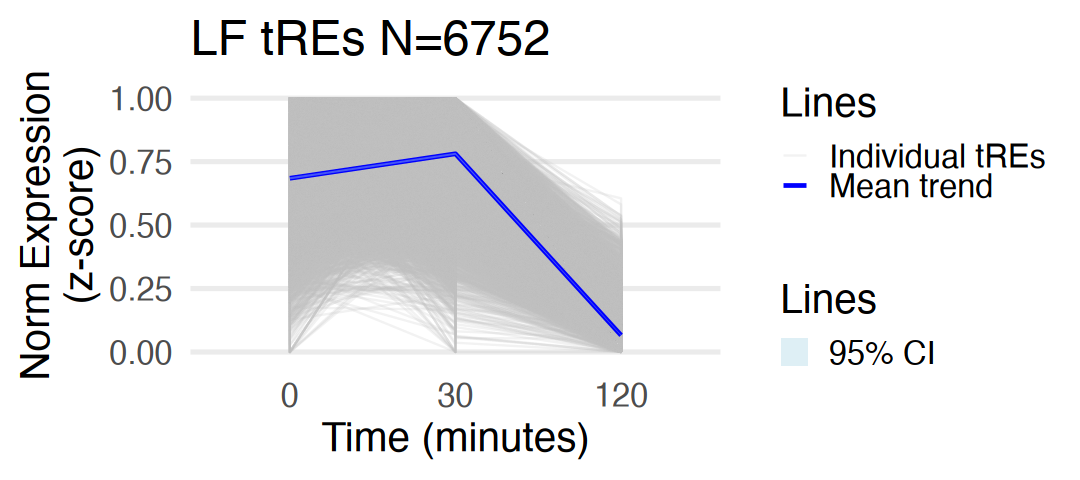

In [ ]:
# Consider with the different time points
options(repr.plot.height=height_use, repr.plot.width=9)
for (timepoint in names(UPM_1_time_sig)) {
    use_genes = UPM_1_time_sig[[timepoint]]
# Step 3: Plot: Mean ± 95% CI per time point
p = ggplot(counts_upm_scaled[counts_upm_scaled$Gene %in% use_genes,], aes(x = Time, y = Scaled)) +
    geom_line(aes(group = Gene, color = "Individual tREs"), alpha = 0.2) +
  stat_summary(fun = mean, geom = "line", aes(group = 1, color = "Mean trend"), linewidth = 1) +
  stat_summary(fun.data = mean_cl_normal, geom = "ribbon", aes(group = 1, fill = "95% CI"),  alpha = 0.4) +
  theme_minimal(base_size = 24) +
  labs(
    title = paste0(timepoint, " tREs N=", length(use_genes)),
    y = "Norm Expression\n(z-score)",
    x = "Time (minutes)"
  ) +
    scale_color_manual(name = "Lines", values = c(
    "Individual tREs" = "gray",
    "Mean trend" = "blue"
  )) +
  scale_fill_manual(name = "Lines", values = c(
    "95% CI" = "lightblue"
  )) +
  theme(
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.minor.y = element_blank()
  )
    print(p)
    ggsave(paste0(timepoint, "_p10_meta_plot_tRE.pdf"), height=height_use, width=9)
    }

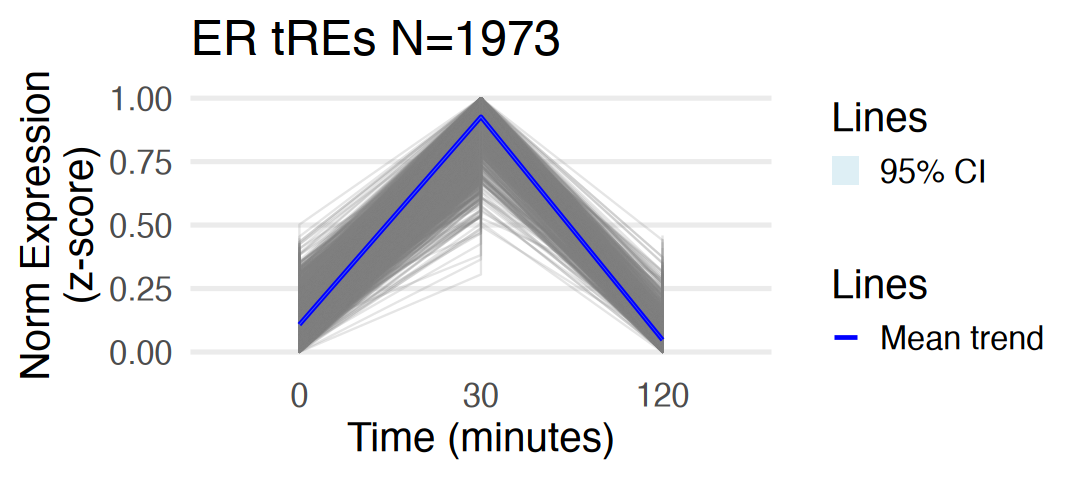

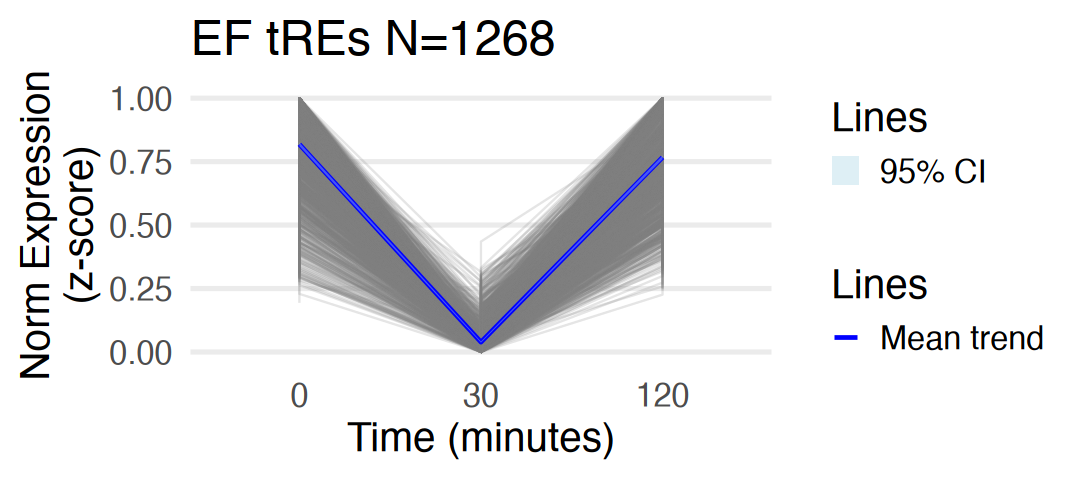

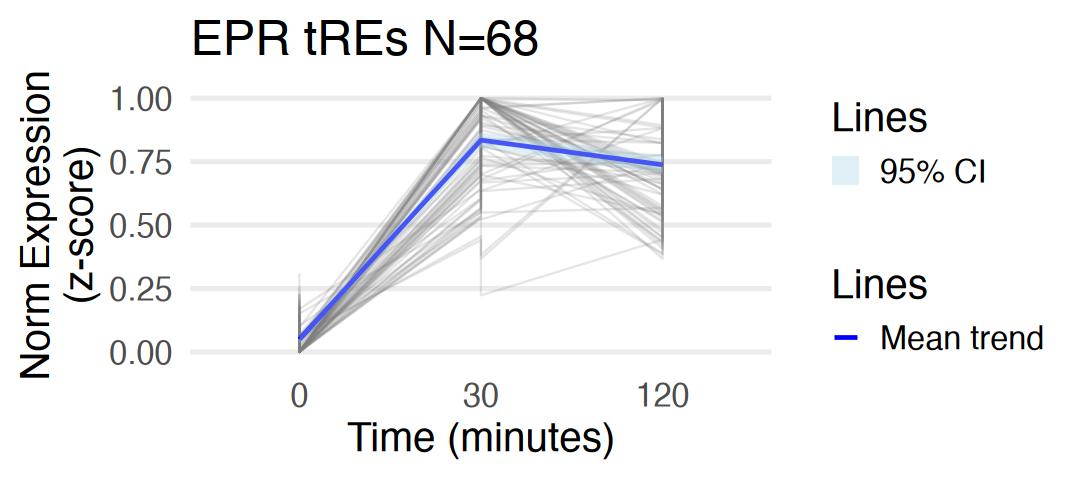

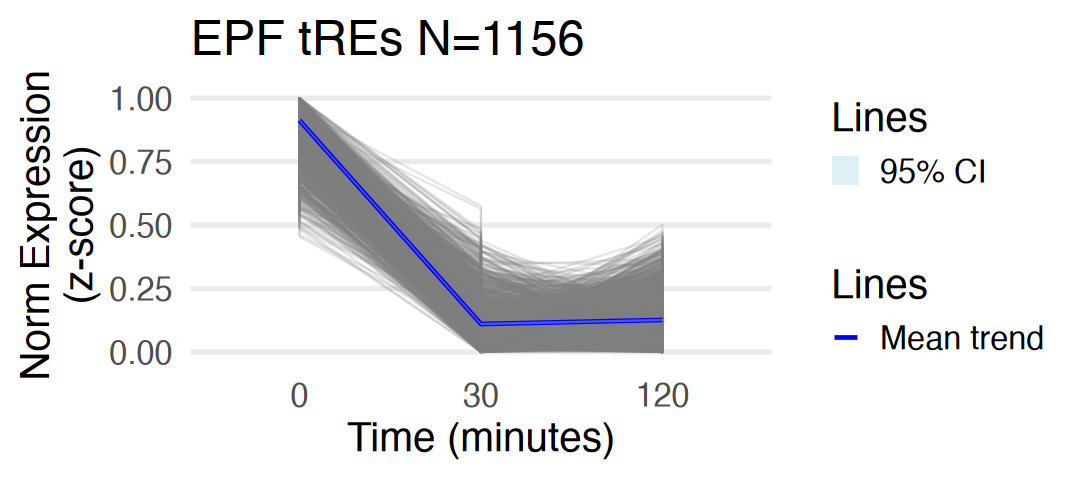

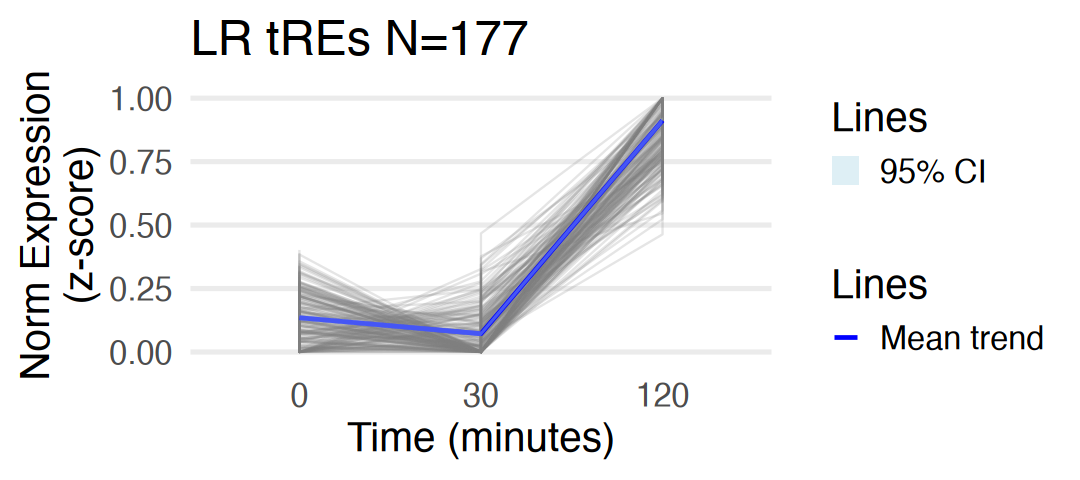

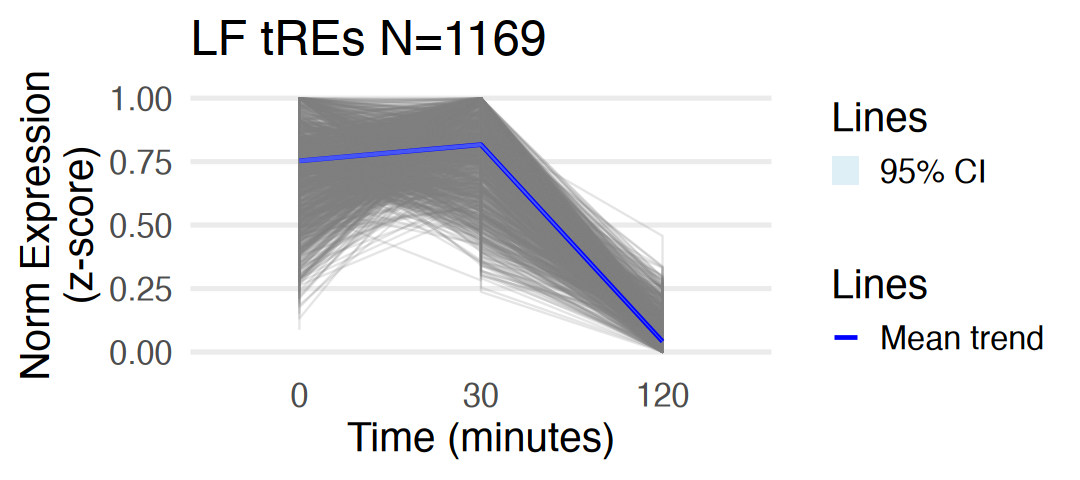

In [24]:
# Consider with the different time points
options(repr.plot.height=height_use, repr.plot.width=9)
for (timepoint in names(WSP_1_time_sig)) {
    use_genes = WSP_1_time_sig[[timepoint]]
# Step 3: Plot: Mean ± 95% CI per time point
p = ggplot(counts_wsp_scaled[counts_wsp_scaled$Gene %in% use_genes,], aes(x = Time, y = Scaled)) +
    geom_line(aes(group = Gene, color = "Individual tREs"), alpha = 0.2) +
  stat_summary(fun = mean, geom = "line", aes(group = 1, color = "Mean trend"), linewidth = 1) +
  stat_summary(fun.data = mean_cl_normal, geom = "ribbon", aes(group = 1, fill = "95% CI"),  alpha = 0.4) +
  theme_minimal(base_size = 24) +
  labs(
    title = paste0(timepoint, " tREs N=", length(use_genes)),
    y = "Norm Expression\n(z-score)",
    x = "Time (minutes)"
  ) +
    scale_color_manual(name = "Lines", values = c(
    "Individual genes" = "gray",
    "Mean trend" = "blue"
  )) +
  scale_fill_manual(name = "Lines", values = c(
    "95% CI" = "lightblue"
  )) +
  theme(
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.minor.y = element_blank()
  )
    print(p)
    ggsave(paste0("WSP_", timepoint, "_tRE_p10_meta_plot.pdf"), height=height_use, width=9)
    }

## Compare the calls to WSP

In [40]:
names(WSP_1_time_sig)
#new_list = list()
WSP_comp_df = data.frame()
options(repr.plot.width=4, repr.plot.height=4)
pdf("./Barplots_UPMtoWSP_tREs.pdf", height=4, width=4)
for (timepoint in names(UPM_10_time_sig)) {
    default_fill = c("ER"="grey", "EF"="grey", "EPR"="grey", 
                     "EPF"="grey", "LR"="grey", "LF"="grey")
    default_fill[[timepoint]] = "blue"
    new_list = list()
    # compare to all the WSP ones
    ER_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["ER"]]))
    EF_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["EF"]]))
    EPR_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["EPR"]]))
    EPF_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["EPF"]]))
    LR_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["LR"]]))
    LF_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["LF"]]))
    # make df with relevant data
    add_comp_df = data.frame(list("UPM_method"=rep(timepoint, 6), 
                                  "WSP_Comparison"=c("ER", "EF", "EPR", "EPF", "LR", "LF"), 
                                 "Num_Shared"=c(ER_shared, EF_shared, 
                                               EPR_shared, EPF_shared, 
                                               LR_shared, LF_shared)))
    add_comp_df$Per_shared = add_comp_df$Num_Shared/length(UPM_10_time_sig[[timepoint]])*100
    WSP_comp_df = rbind(WSP_comp_df, add_comp_df)   
    p <- ggplot(add_comp_df, aes(factor(WSP_Comparison, levels=c("ER", "EF", "EPR", "EPF", "LR", "LF")), y=Per_shared, 
                           fill=WSP_Comparison)) + 
    geom_col() + scale_fill_manual(values=default_fill) + 
    labs(x="WSP tRE Categories", y="% Shared", title=timepoint) + theme_minimal(base_size=20) +
    geom_text(aes(label = Num_Shared), 
            vjust = -0.5, size = 6) +  # adjust vjust and size as needed
    theme(axis.text.x=element_text(angle=90, hjust=1.4, vjust=.5), 
          panel.grid.major.x = element_blank(),
            panel.grid.minor.x = element_blank(),
            panel.grid.minor.y = element_blank(),
          legend.position="FALSE") +
    expand_limits(y = max(add_comp_df$Per_shared, na.rm = TRUE) * 1.1)  # add headroom above bars
    print(p)
    }
dev.off()
lapply(WSP_10_time_sig, length)

[1] "ER"  "EF"  "EPR" "EPF" "LR"  "LF"

pdf 
  2

$ER
[1] 1973

$EF
[1] 1268

$EPR
[1] 68

$EPF
[1] 1156

$LR
[1] 177

$LF
[1] 1169

In [26]:
names(UPM_1_time_sig)
#new_list = list()
UPM_comp_df = data.frame()
options(repr.plot.width=4, repr.plot.height=4)
pdf("./Barplots_WSPtoUPM_tREs.pdf", height=4, width=4)
for (timepoint in names(WSP_10_time_sig)) {
    default_fill = c("ER"="grey", "EF"="grey", "EPR"="grey", 
                     "EPF"="grey", "LR"="grey", "LF"="grey")
    default_fill[[timepoint]] = "blue"
    new_list = list()
    # compare to all the WSP ones
    ER_shared = length(intersect(WSP_10_time_sig[[timepoint]], UPM_10_time_sig[["ER"]]))
    EF_shared = length(intersect(WSP_10_time_sig[[timepoint]], UPM_10_time_sig[["EF"]]))
    EPR_shared = length(intersect(WSP_10_time_sig[[timepoint]], UPM_10_time_sig[["EPR"]]))
    EPF_shared = length(intersect(WSP_10_time_sig[[timepoint]], UPM_10_time_sig[["EPF"]]))
    LR_shared = length(intersect(WSP_10_time_sig[[timepoint]], UPM_10_time_sig[["LR"]]))
    LF_shared = length(intersect(WSP_10_time_sig[[timepoint]], UPM_10_time_sig[["LF"]]))
    # make df with relevant data
    add_comp_df = data.frame(list("WSP_method"=rep(timepoint, 6), 
                                  "UPM_Comparison"=c("ER", "EF", "EPR", "EPF", "LR", "LF"), 
                                 "Num_Shared"=c(ER_shared, EF_shared, 
                                               EPR_shared, EPF_shared, 
                                               LR_shared, LF_shared)))
    add_comp_df$Per_shared = add_comp_df$Num_Shared/length(WSP_10_time_sig[[timepoint]])*100
    UPM_comp_df = rbind(UPM_comp_df, add_comp_df)   
    p <- ggplot(add_comp_df, aes(factor(UPM_Comparison, levels=c("ER", "EF", "EPR", "EPF", "LR", "LF")), y=Per_shared, 
                           fill=UPM_Comparison)) + 
    geom_col() + scale_fill_manual(values=default_fill) + 
    labs(x="UPM tRE Categories", y="% Shared", title=timepoint) + theme_minimal(base_size=20) +
    geom_text(aes(label = Num_Shared), 
            vjust = -0.5, size = 6) +  # adjust vjust and size as needed
    theme(axis.text.x=element_text(angle=90, hjust=1.4, vjust=.5), 
          panel.grid.major.x = element_blank(),
            panel.grid.minor.x = element_blank(),
            panel.grid.minor.y = element_blank(),
          legend.position="FALSE") +
    expand_limits(y = max(add_comp_df$Per_shared, na.rm = TRUE) * 1.1)  # add headroom above bars
    print(p)
    }
dev.off()
lapply(UPM_10_time_sig, length)

[1] "ER"  "EF"  "EPR" "EPF" "LR"  "LF"

pdf 
  2

$ER
[1] 3290

$EF
[1] 831

$EPR
[1] 117

$EPF
[1] 1993

$LR
[1] 19

$LF
[1] 6752

[1] "ER"  "EF"  "EPR" "EPF" "LR"  "LF"

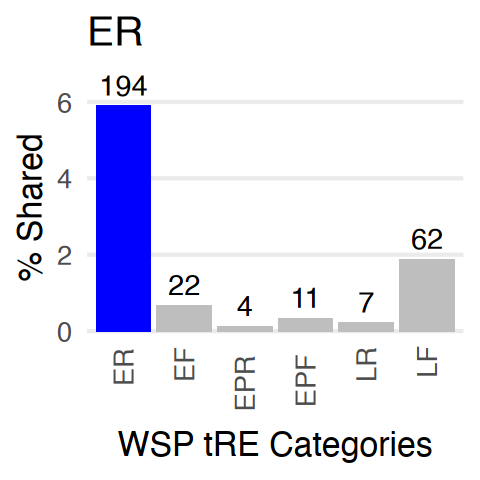

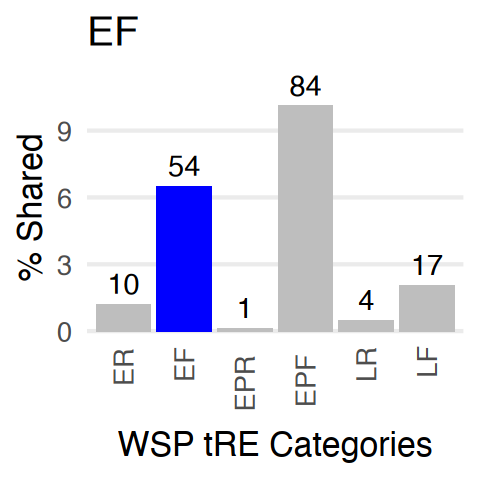

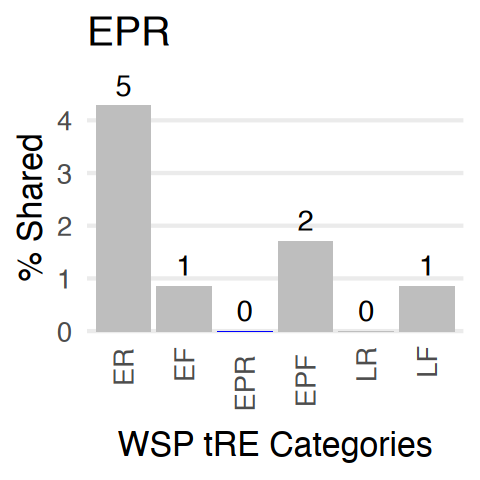

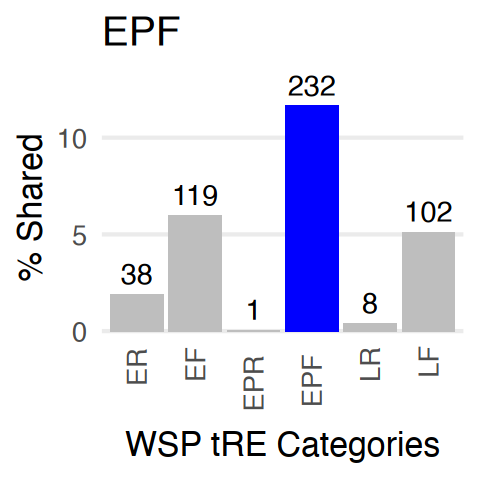

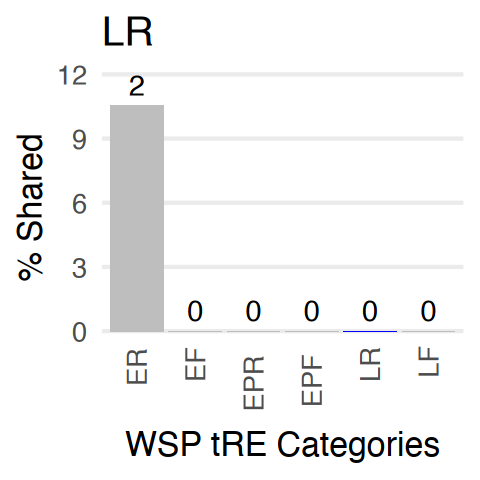

$ER
[1] 1973

$EF
[1] 1268

$EPR
[1] 68

$EPF
[1] 1156

$LR
[1] 177

$LF
[1] 1169

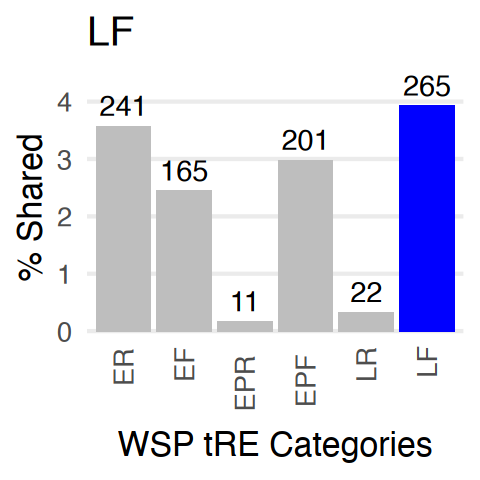

In [41]:
names(WSP_1_time_sig)
#new_list = list()
WSP_comp_df = data.frame()
options(repr.plot.width=4, repr.plot.height=4)
for (timepoint in names(UPM_10_time_sig)) {
    default_fill = c("ER"="grey", "EF"="grey", "EPR"="grey", 
                     "EPF"="grey", "LR"="grey", "LF"="grey")
    default_fill[[timepoint]] = "blue"
    new_list = list()
    # compare to all the WSP ones
    ER_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["ER"]]))
    EF_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["EF"]]))
    EPR_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["EPR"]]))
    EPF_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["EPF"]]))
    LR_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["LR"]]))
    LF_shared = length(intersect(UPM_10_time_sig[[timepoint]], WSP_10_time_sig[["LF"]]))
    # make df with relevant data
    add_comp_df = data.frame(list("UPM_method"=rep(timepoint, 6), 
                                  "WSP_Comparison"=c("ER", "EF", "EPR", "EPF", "LR", "LF"), 
                                 "Num_Shared"=c(ER_shared, EF_shared, 
                                               EPR_shared, EPF_shared, 
                                               LR_shared, LF_shared)))
    add_comp_df$Per_shared = add_comp_df$Num_Shared/length(UPM_10_time_sig[[timepoint]])*100
    WSP_comp_df = rbind(WSP_comp_df, add_comp_df)   
    p <- ggplot(add_comp_df, aes(factor(WSP_Comparison, levels=c("ER", "EF", "EPR", "EPF", "LR", "LF")), y=Per_shared, 
                           fill=WSP_Comparison)) + 
    geom_col() + scale_fill_manual(values=default_fill) + 
    labs(x="WSP tRE Categories", y="% Shared", title=timepoint) + theme_minimal(base_size=20) +
    geom_text(aes(label = Num_Shared), 
            vjust = -0.5, size = 6) +  # adjust vjust and size as needed
    theme(axis.text.x=element_text(angle=90, hjust=1.4, vjust=.5), 
          panel.grid.major.x = element_blank(),
            panel.grid.minor.x = element_blank(),
            panel.grid.minor.y = element_blank(),
          legend.position="FALSE") +
    expand_limits(y = max(add_comp_df$Per_shared, na.rm = TRUE) * 1.1)  # add headroom above bars
    print(p)
    }

lapply(WSP_10_time_sig, length)